# TOUTES LES ETAPES DE L'EXPLORATION 

# CHARGEMENT & INSPECTION AVANCEE

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset_anomalies.csv")
df_util = df.copy()
df_util.head()

,Age,Revenu,Genre,IMC,Achats,Score_Credit,Nombre_Enfants,Statut_Marital,Ville,Depenses_Mensuelles,Epargne,Temps_Travail,Satisfaction_Client,Anciennete_Client,Score_Sante
0,54,72134.0,Homme,37.0,41,337,2,Marié,Dakar,21230.0,9013.0,50,3,15,18
1,67,147413.0,Homme,35.0,38,324,0,Célibataire,Kaolack,93301.0,39113.0,11,4,17,1
2,44,105327.0,Femme,19.4,24,709,4,Marié,Kaolack,15902.0,3574.0,28,5,8,91
3,30,146410.0,Homme,29.1,45,760,3,Divorcé,Thiès,76758.0,32480.0,25,3,3,95
4,58,26344.0,Homme,18.5,31,716,2,Marié,Kaolack,37050.0,7838.0,52,1,8,61


## 1. CONTEXTE ET OBJECTIF

#### Observation

Le dataset contient des informations socio-économiques et comportementales sur des individus (revenu, épargne, dépenses, score de crédit, satisfaction et autres.).

#### Interprétation

Ces données sont typiques d'un contexte :

    bancaire
    marketing
    gestion de la relation client

#### Conclusion

L'objectif de l'analyse est de :

    comprendre les profils clients
    identifier des segments
    orienter la prise de décision stratégique

In [3]:
df_util.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2020 non-null   int64  
 1   Revenu               1968 non-null   object 
 2   Genre                2020 non-null   object 
 3   IMC                  1970 non-null   object 
 4   Achats               2020 non-null   int64  
 5   Score_Credit         2020 non-null   int64  
 6   Nombre_Enfants       2020 non-null   int64  
 7   Statut_Marital       2020 non-null   object 
 8   Ville                2020 non-null   object 
 9   Depenses_Mensuelles  1970 non-null   float64
 10  Epargne              2020 non-null   float64
 11  Temps_Travail        2020 non-null   int64  
 12  Satisfaction_Client  2020 non-null   int64  
 13  Anciennete_Client    2020 non-null   int64  
 14  Score_Sante          2020 non-null   int64  
dtypes: float64(2), int64(8), object(5)
mem

In [4]:
col_mixted = []

for col in df_util.columns:
    nomb_types = df_util[col].apply(type).value_counts()
    
    if len(nomb_types) > 1:
        print(nomb_types)
        col_mixted.append(col)

Revenu
<class 'str'>      1968
<class 'float'>      52
Name: count, dtype: int64
IMC
<class 'str'>      1970
<class 'float'>      50
Name: count, dtype: int64


In [5]:
df_util.isnull().sum()

Age                     0
Revenu                 52
Genre                   0
IMC                    50
Achats                  0
Score_Credit            0
Nombre_Enfants          0
Statut_Marital          0
Ville                   0
Depenses_Mensuelles    50
Epargne                 0
Temps_Travail           0
Satisfaction_Client     0
Anciennete_Client       0
Score_Sante             0
dtype: int64

In [6]:
for col in df_util.columns:
    print(f"\n{col}")
    print(df_util[col].astype(str).unique()[:30])


Age
['54' '67' '44' '30' '58' '23' '76' '36' '73' '34' '38' '26' '39' '68'
 '51' '55' '18' '37' '17' '59' '45' '53' '79' '75' '48' '27' '40' '64'
 '42' '74']

Revenu
['72134.0' '147413.0' '105327.0' '146410.0' '26344.0' '147822.0' '82957.0'
 '120423.0' '73053.0' 'nan' '105600.0' '137732.0' '52641.0' '44711.0'
 '121896.0' '71276.0' '34541.0' '109457.0' 'erreur' '39070.0' '95559.0'
 '56786.0' '51062.0' '66571.0' '40510.0' '34426.0' '52265.0' '81150.0'
 '1000000' '104613.0']

Genre
['Homme' 'Femme' 'Autre']

IMC
['37.0' '35.0' '19.4' '29.1' '18.5' '17.1' '31.8' '28.8' '18.0' '16.8'
 'inconnu' '16.7' '26.7' '28.1' '18.8' '20.1' '24.4' '34.3' '28.2' '31.3'
 '39.6' '34.4' '26.4' '30.9' '32.0' '28.0' '31.5' '16.6' '26.3' '22.7']

Achats
['41' '38' '24' '45' '31' '23' '47' '46' '43' '8' '39' '49' '22' '12' '14'
 '35' '48' '4' '21' '15' '40' '9' '17' '6' '3' '25' '34' '28' '13' '32']

Score_Credit
['337' '324' '709' '760' '716' '656' '682' '457' '732' '347' '627' '730'
 '355' '567' '368' '748'

In [7]:
for col in df_util.columns:
    freq = df_util[col].astype(str).value_counts(normalize=True)
    
    val_rare = freq[freq < 0.01]
    
    if not val_rare.empty:
        print(f"\n valeurs rares : {val_rare} ") 


 valeurs rares : Age
12    0.000495
Name: proportion, dtype: float64 

 valeurs rares : Revenu
72134.0     0.001485
105327.0    0.000990
146410.0    0.000990
26344.0     0.000990
45682.0     0.000990
              ...   
34477.0     0.000495
142815.0    0.000495
142426.0    0.000495
39335.0     0.000495
54121.0     0.000495
Name: proportion, Length: 1940, dtype: float64 

 valeurs rares : Genre
Autre    0.000495
Name: proportion, dtype: float64 

 valeurs rares : IMC
26.7       0.008416
28.3       0.008416
19.3       0.007921
23.6       0.007426
17.3       0.007426
             ...   
inconnu    0.000990
24.5       0.000990
37.2       0.000990
120        0.000495
19.8       0.000495
Name: proportion, Length: 243, dtype: float64 

 valeurs rares : Score_Credit
716    0.005941
763    0.005446
801    0.004950
394    0.004950
520    0.004455
         ...   
329    0.000495
519    0.000495
613    0.000495
397    0.000495
505    0.000495
Name: proportion, Length: 534, dtype: float64 

 vale

In [8]:
df_util['Revenu'].describe()

count        1968
unique       1940
top       72134.0
freq            3
Name: Revenu, dtype: object

In [9]:
# étape 1
df_util['Revenu'] = pd.to_numeric(df_util['Revenu'], errors='coerce')
df_util['IMC'] = pd.to_numeric(df_util['IMC'], errors='coerce')

# étape 2
num_cols = df_util.select_dtypes(include='number').columns
cat_cols = df_util.select_dtypes(include='object').columns

In [10]:
df_util.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2020 non-null   int64  
 1   Revenu               1967 non-null   float64
 2   Genre                2020 non-null   object 
 3   IMC                  1968 non-null   float64
 4   Achats               2020 non-null   int64  
 5   Score_Credit         2020 non-null   int64  
 6   Nombre_Enfants       2020 non-null   int64  
 7   Statut_Marital       2020 non-null   object 
 8   Ville                2020 non-null   object 
 9   Depenses_Mensuelles  1970 non-null   float64
 10  Epargne              2020 non-null   float64
 11  Temps_Travail        2020 non-null   int64  
 12  Satisfaction_Client  2020 non-null   int64  
 13  Anciennete_Client    2020 non-null   int64  
 14  Score_Sante          2020 non-null   int64  
dtypes: float64(4), int64(8), object(3)
mem

In [11]:
for col_name in num_cols:
    
    print(f"VARIABLE NUMERIQUE : {col_name}")
    
    col = df_util[col_name]
    
    # 1. vrais NaN
    vrai_nan = col.isnull().sum()
    
    print("NaN :", vrai_nan)
    
    # 2. valeurs problématiques (ex: inf)
    import numpy as np
    inf_count = np.isinf(col).sum()
    
    print("Valeurs infinies :", inf_count)
    
    # 3. statistiques simples
    #print("\nStatistiques :")
    #print(col.describe())
    
    # 4. vérification du type
    print("\nType :", col.dtype)

VARIABLE NUMERIQUE : Age
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Revenu
NaN : 53
Valeurs infinies : 0

Type : float64
VARIABLE NUMERIQUE : IMC
NaN : 52
Valeurs infinies : 0

Type : float64
VARIABLE NUMERIQUE : Achats
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Score_Credit
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Nombre_Enfants
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Depenses_Mensuelles
NaN : 50
Valeurs infinies : 0

Type : float64
VARIABLE NUMERIQUE : Epargne
NaN : 0
Valeurs infinies : 0

Type : float64
VARIABLE NUMERIQUE : Temps_Travail
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Satisfaction_Client
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Anciennete_Client
NaN : 0
Valeurs infinies : 0

Type : int64
VARIABLE NUMERIQUE : Score_Sante
NaN : 0
Valeurs infinies : 0

Type : int64


In [12]:
for col_name in cat_cols:
    
    print(f"VARIABLE CATEGORIELLE : {col_name}")
    
    col = df_util[col_name]
    
    # 1. vrais NaN
    vrai_nan = col.isnull().sum()
    
    # 2. faux NaN (texte)
    col_clean = col.astype(str).str.strip().str.lower()
    
    faux_nan = col_clean.isin(["nan", "na", "n/a", "null", "none", "?", "-", "unknown"]).sum()
    
    # 3. affichage
    print("Vrai NaN :", vrai_nan)
    print("Faux manquants :", faux_nan)
    
    # 4. valeurs problématiques
    print("\nValeurs problématiques :")
    print(col[col_clean.isin(["nan", "na", "n/a", "null", "none", "?", "-", "unknown"])].value_counts())
    
    # 5. standardisation (TRÈS IMPORTANT)
    df_util[col_name] = col.astype(str).str.strip().str.lower()
    
    # 6. vérification
    print("\nModalités uniques :")
    print(df_util[col_name].value_counts().head())

VARIABLE CATEGORIELLE : Genre
Vrai NaN : 0
Faux manquants : 0

Valeurs problématiques :
Series([], Name: count, dtype: int64)

Modalités uniques :
Genre
homme    1013
femme    1006
autre       1
Name: count, dtype: int64
VARIABLE CATEGORIELLE : Statut_Marital
Vrai NaN : 0
Faux manquants : 0

Valeurs problématiques :
Series([], Name: count, dtype: int64)

Modalités uniques :
Statut_Marital
marié          691
divorcé        683
célibataire    645
inconnu          1
Name: count, dtype: int64
VARIABLE CATEGORIELLE : Ville
Vrai NaN : 0
Faux manquants : 0

Valeurs problématiques :
Series([], Name: count, dtype: int64)

Modalités uniques :
Ville
dakar          522
saint-louis    512
thiès          499
kaolack        487
Name: count, dtype: int64


In [13]:
df_util.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2020 non-null   int64  
 1   Revenu               1967 non-null   float64
 2   Genre                2020 non-null   object 
 3   IMC                  1968 non-null   float64
 4   Achats               2020 non-null   int64  
 5   Score_Credit         2020 non-null   int64  
 6   Nombre_Enfants       2020 non-null   int64  
 7   Statut_Marital       2020 non-null   object 
 8   Ville                2020 non-null   object 
 9   Depenses_Mensuelles  1970 non-null   float64
 10  Epargne              2020 non-null   float64
 11  Temps_Travail        2020 non-null   int64  
 12  Satisfaction_Client  2020 non-null   int64  
 13  Anciennete_Client    2020 non-null   int64  
 14  Score_Sante          2020 non-null   int64  
dtypes: float64(4), int64(8), object(3)
mem

In [14]:
for col in df_util.columns:
    print(f"\n{col}")
    print(df_util[col].astype(str).unique()[:50])


Age
['54' '67' '44' '30' '58' '23' '76' '36' '73' '34' '38' '26' '39' '68'
 '51' '55' '18' '37' '17' '59' '45' '53' '79' '75' '48' '27' '40' '64'
 '42' '74' '78' '57' '43' '31' '77' '62' '66' '70' '72' '52' '12' '22'
 '24' '33' '19' '29' '65' '41' '35' '50']

Revenu
['72134.0' '147413.0' '105327.0' '146410.0' '26344.0' '147822.0' '82957.0'
 '120423.0' '73053.0' 'nan' '105600.0' '137732.0' '52641.0' '44711.0'
 '121896.0' '71276.0' '34541.0' '109457.0' '39070.0' '95559.0' '56786.0'
 '51062.0' '66571.0' '40510.0' '34426.0' '52265.0' '81150.0' '1000000.0'
 '104613.0' '89910.0' '67375.0' '136826.0' '50435.0' '111443.0' '149055.0'
 '38510.0' '109071.0' '59547.0' '69620.0' '130608.0' '22564.0' '128824.0'
 '94273.0' '89859.0' '125017.0' '138618.0' '140341.0' '44430.0' '42788.0'
 '84346.0']

Genre
['homme' 'femme' 'autre']

IMC
['37.0' '35.0' '19.4' '29.1' '18.5' '17.1' '31.8' '28.8' '18.0' '16.8'
 'nan' '16.7' '26.7' '28.1' '18.8' '20.1' '24.4' '34.3' '28.2' '31.3'
 '39.6' '34.4' '26.4' '30.9

In [15]:
for col in df_util.columns:
    freq = df_util[col].astype(str).value_counts(normalize=True)
    
    val_rare = freq[freq < 0.01]
    
    if not val_rare.empty:
        print(f"\n valeurs rares : {val_rare} ")       


 valeurs rares : Age
12    0.000495
Name: proportion, dtype: float64 

 valeurs rares : Revenu
72134.0     0.001485
147413.0    0.000990
105327.0    0.000990
146410.0    0.000990
26344.0     0.000990
              ...   
34477.0     0.000495
142815.0    0.000495
142426.0    0.000495
39335.0     0.000495
133639.0    0.000495
Name: proportion, Length: 1939, dtype: float64 

 valeurs rares : Genre
autre    0.000495
Name: proportion, dtype: float64 

 valeurs rares : IMC
26.7     0.008416
28.3     0.008416
19.3     0.007921
23.6     0.007426
17.3     0.007426
           ...   
29.4     0.000990
24.5     0.000990
37.2     0.000990
120.0    0.000495
19.8     0.000495
Name: proportion, Length: 242, dtype: float64 

 valeurs rares : Score_Credit
716    0.005941
763    0.005446
801    0.004950
394    0.004950
520    0.004455
         ...   
329    0.000495
519    0.000495
613    0.000495
397    0.000495
505    0.000495
Name: proportion, Length: 534, dtype: float64 

 valeurs rares : Statut_Mar

In [16]:
# traiter les faux manquants catégoriels

for col in ['Statut_Marital']:
    
    print(f"\nTraitement de {col}")
    
    print("Avant :")
    print(df_util[col].value_counts(dropna=False))
    
    # correction
    df_util[col] = df_util[col].replace('inconnu', np.nan)
    
    print("\nAprès :")
    print(df_util[col].value_counts(dropna=False))


Traitement de Statut_Marital
Avant :


Statut_Marital
marié          691
divorcé        683
célibataire    645
inconnu          1
Name: count, dtype: int64

Après :
Statut_Marital
marié          691
divorcé        683
célibataire    645
NaN              1
Name: count, dtype: int64


In [17]:
df_util['Genre'] = df_util['Genre'].replace('autre', np.nan)

In [18]:
print(df_util['Genre'].value_counts(dropna=False))

Genre
homme    1013
femme    1006
NaN         1
Name: count, dtype: int64


In [19]:
#freq = df_util['Genre'].value_counts()

#if freq.min() <= 1:
    #df_util['Genre'] = df_util['Genre'].replace(freq.idxmin(), np.nan)

In [20]:
df_util.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2020.0,48.243069,18.563942,12.0,33.00,48.0,64.00,79.0
Revenu,1967.0,81875.809354,43827.855205,-5000.0,47498.50,80942.0,113782.00,1000000.0
IMC,1968.0,27.703404,7.280535,16.0,21.60,27.6,33.70,120.0
Achats,2020.0,24.477723,14.257033,0.0,12.00,24.0,37.00,49.0
Score_Credit,2020.0,578.317822,161.036271,300.0,438.75,573.0,723.00,1000.0
Nombre_Enfants,2020.0,2.529703,1.713972,0.0,1.00,3.0,4.00,5.0
Depenses_Mensuelles,1970.0,54442.402030,26088.634856,10042.0,31902.50,54762.0,76798.50,99905.0
Epargne,2020.0,24966.110891,14405.036006,-2000.0,12941.00,24550.5,37483.25,49999.0
Temps_Travail,2020.0,34.732673,14.440561,10.0,22.00,35.0,47.00,59.0
Satisfaction_Client,2020.0,3.026733,1.413961,1.0,2.00,3.0,4.00,5.0


In [21]:
df_util.isnull().sum()

Age                     0
Revenu                 53
Genre                   1
IMC                    52
Achats                  0
Score_Credit            0
Nombre_Enfants          0
Statut_Marital          1
Ville                   0
Depenses_Mensuelles    50
Epargne                 0
Temps_Travail           0
Satisfaction_Client     0
Anciennete_Client       0
Score_Sante             0
dtype: int64

In [22]:
for col in ['Revenu', 'Epargne']:
    if col in df_util.columns:
        print(f"\n{col}")
        print("Négatifs :", (df_util[col] < 0).sum())


Revenu
Négatifs : 1

Epargne
Négatifs : 1


In [23]:
# Revenu
df_util.loc[df_util['Revenu'] < 0, 'Revenu'] = np.nan

# Epargne
df_util.loc[df_util['Epargne'] < 0, 'Epargne'] = np.nan

In [24]:
print("Revenu négatifs :", (df_util['Revenu'] < 0).sum())
print("Epargne négatifs :", (df_util['Epargne'] < 0).sum())

Revenu négatifs : 0
Epargne négatifs : 0


In [25]:
df_util = df_util[(df_util['Revenu'] >= 0) & (df_util['Epargne'] >= 0)]

In [26]:
df_util.to_csv("df_util_modif.csv", index=False)

In [27]:
manq_cach = ["", " ", "NA", "N/A", "null", "None", "?"]
df.replace(manq_cach, np.nan, inplace=True)

In [28]:
df_util.duplicated().sum()
df_util = df_util.drop_duplicates()

In [29]:
# Nombre de valeurs distinctes par colonne
df_util.nunique()


Age                      65
Revenu                 1937
Genre                     2
IMC                     241
Achats                   50
Score_Credit            529
Nombre_Enfants            6
Statut_Marital            3
Ville                     4
Depenses_Mensuelles    1881
Epargne                1913
Temps_Travail            50
Satisfaction_Client       5
Anciennete_Client        20
Score_Sante             100
dtype: int64

In [30]:
nunique = df_util.nunique()
constant_cols = nunique[nunique <= 1]
df_util.drop(columns=constant_cols.index, inplace=True)

In [31]:
# 1. sélectionner les variables numériques
num_df = df_util.select_dtypes(include=np.number)

# 2. appliquer VarianceThreshold
sel = VarianceThreshold(0.01)
sel.fit(num_df)

# 3. récupérer les colonnes à faible variance
low_var_cols = num_df.columns[~sel.get_support()]

# 4. AFFICHAGE
print("Colonnes numériques analysées :", list(num_df.columns))
print("\nColonnes à faible variance :", list(low_var_cols))

# 5. suppression
df_util.drop(columns=low_var_cols, inplace=True)

# 6. vérification finale
print("\nShape après suppression :", df_util.shape)

Colonnes numériques analysées : ['Age', 'Revenu', 'IMC', 'Achats', 'Score_Credit', 'Nombre_Enfants', 'Depenses_Mensuelles', 'Epargne', 'Temps_Travail', 'Satisfaction_Client', 'Anciennete_Client', 'Score_Sante']

Colonnes à faible variance : []

Shape après suppression : (1948, 15)


In [32]:
df_util.isna().sum()

Age                     0
Revenu                  0
Genre                   1
IMC                    51
Achats                  0
Score_Credit            0
Nombre_Enfants          0
Statut_Marital          1
Ville                   0
Depenses_Mensuelles    49
Epargne                 0
Temps_Travail           0
Satisfaction_Client     0
Anciennete_Client       0
Score_Sante             0
dtype: int64

In [33]:
df_util.describe()

,Age,Revenu,IMC,Achats,Score_Credit,Nombre_Enfants,Depenses_Mensuelles,Epargne,Temps_Travail,Satisfaction_Client,Anciennete_Client,Score_Sante
count,1948.000000,1948.000000,1897.000000,1948.000000,1948.000000,1948.000000,1899.000000,1948.000000,1948.000000,1948.000000,1948.000000,1948.000000
mean,48.289014,81782.031314,27.658672,24.304928,578.742813,2.539014,54526.948920,24895.178645,34.783881,3.029261,9.556468,49.829055
std,18.616122,43806.687493,6.980581,14.242288,161.212541,1.713422,26141.546987,14365.827342,14.433846,1.417720,5.716680,29.171597
min,12.000000,15138.000000,16.000000,0.000000,300.000000,0.000000,10042.000000,18.000000,10.000000,1.000000,0.000000,0.000000
25%,33.000000,47438.250000,21.600000,12.000000,439.750000,1.000000,31719.000000,12938.750000,22.000000,2.000000,4.000000,24.000000
50%,48.000000,80745.500000,27.600000,24.000000,573.000000,3.000000,54846.000000,24513.500000,35.000000,3.000000,10.000000,50.500000
75%,65.000000,113702.750000,33.700000,37.000000,724.000000,4.000000,76976.500000,37429.750000,47.000000,4.000000,14.000000,75.000000
max,79.000000,1000000.000000,40.000000,49.000000,1000.000000,5.000000,99905.000000,49999.000000,59.000000,5.000000,19.000000,99.000000


## 2. QUALITÉ DES DONNÉES (INSPECTION)

#### Observation

Présence de variables mal typées (Revenu, IMC)

Valeurs manquantes significatives

Valeurs incohérentes :

    Revenu négatif
    
    Épargne négative
    
    IMC extrême (120)

Modalités problématiques :

    "autre" (très rare)
    "inconnu"

#### Interprétation

Les données présentent des défauts classiques des données réelles :

    erreurs de saisie

    incohérences métier

    valeurs aberrantes

#### Conclusion

Les données nécessitent un nettoyage rigoureux avant toute analyse fiable.

## 3. PRÉPARATION DES DONNÉES

#### Observation

Les opérations suivantes ont été réalisées :

    conversion des types (Revenu, IMC)
    remplacement des valeurs incohérentes par NaN
    traitement des valeurs manquantes :
    médiane (numériques)
    mode (catégorielles)
    correction des modalités rares et incohérentes
    suppression des doublons
    aucune variable à faible variance détectée

#### Interprétation

Le dataset a été correctement préparé :

    homogénéisation des formats
    suppression du bruit
    conservation de l'information utile

#### Conclusion

Les données sont désormais fiables et prêtes pour l'analyse statistique.

In [34]:
from scipy.stats import pearsonr, spearmanr, chi2_contingency, f_oneway, kruskal, shapiro, levene

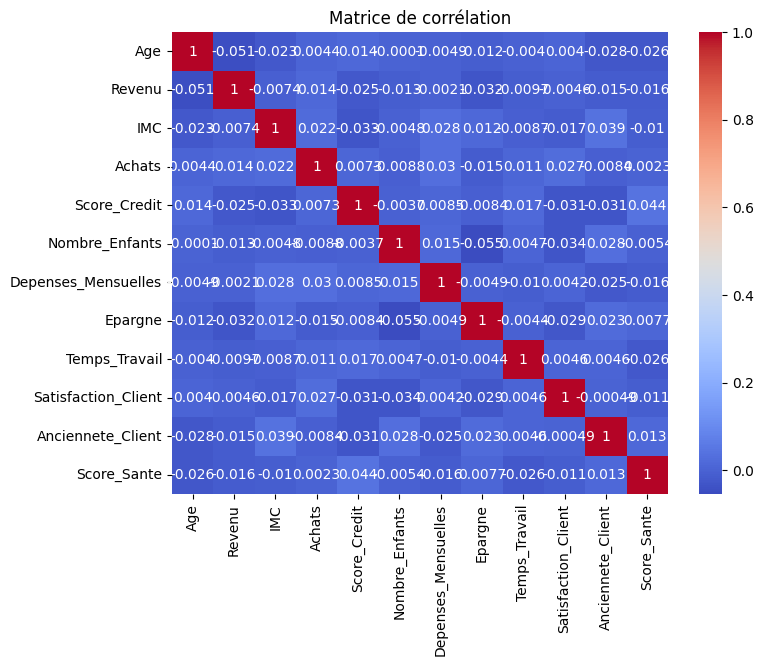

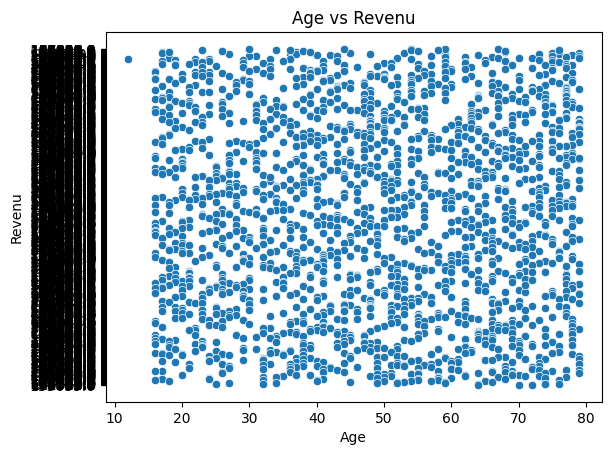

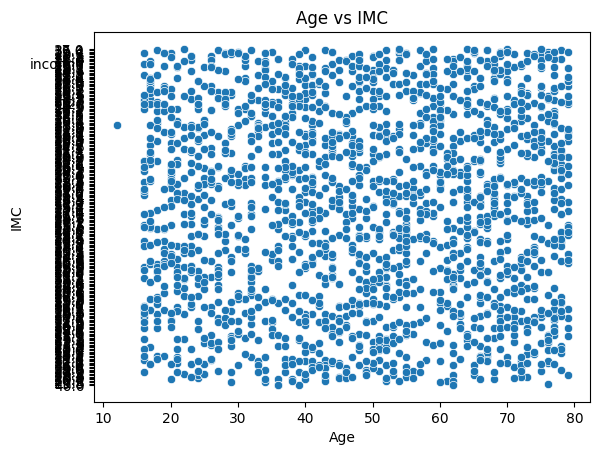

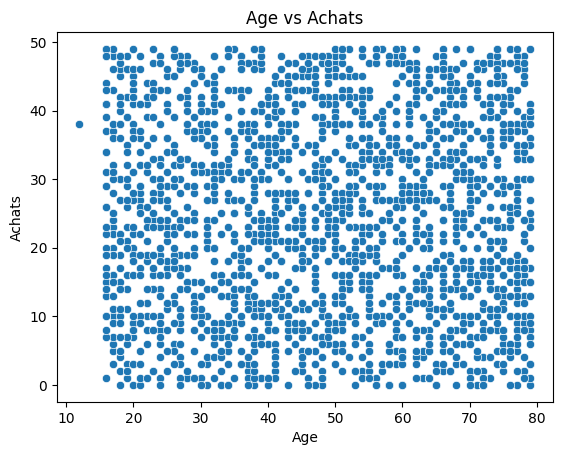

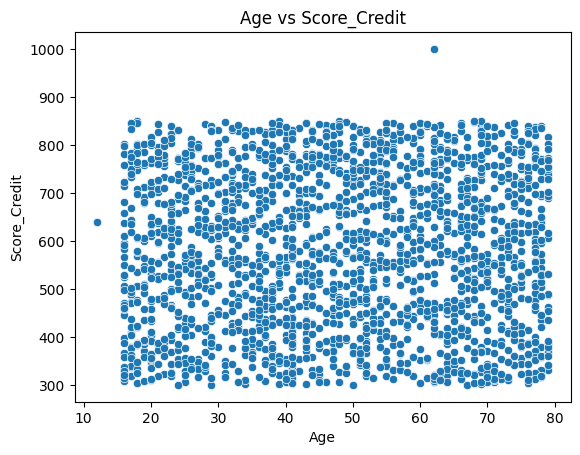

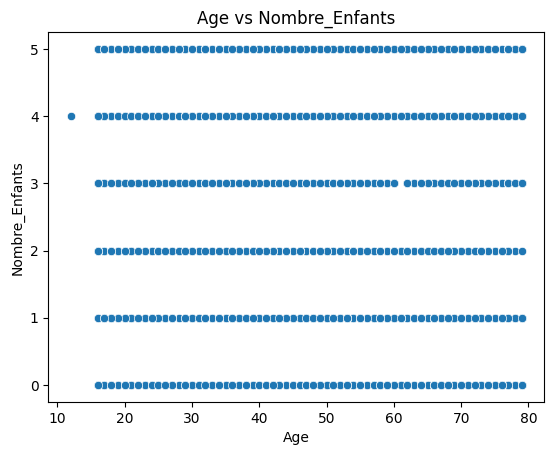

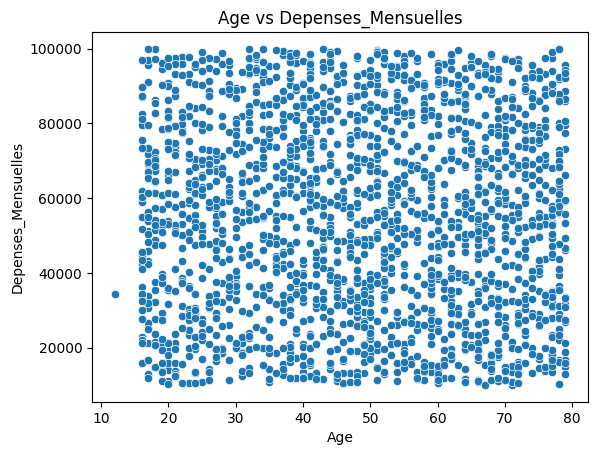

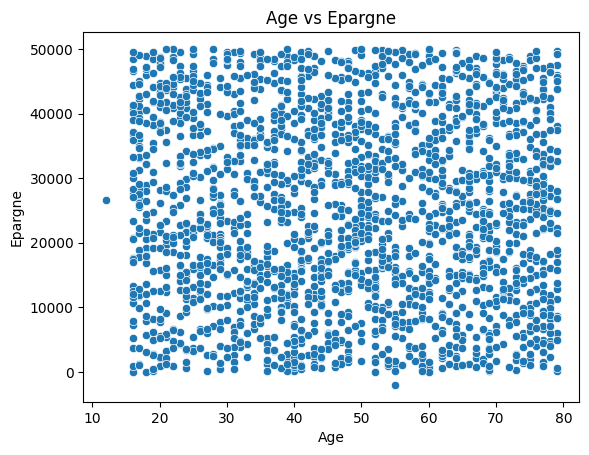

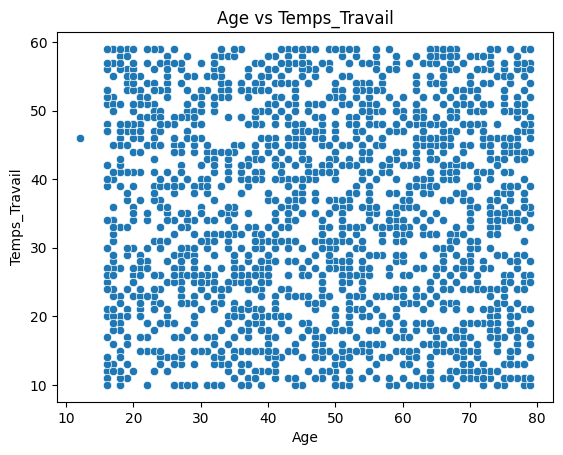

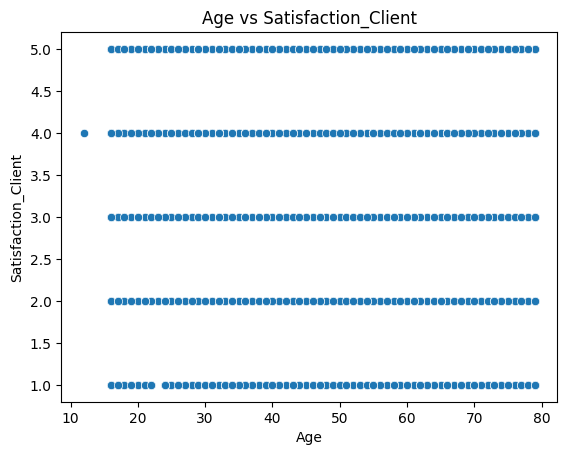

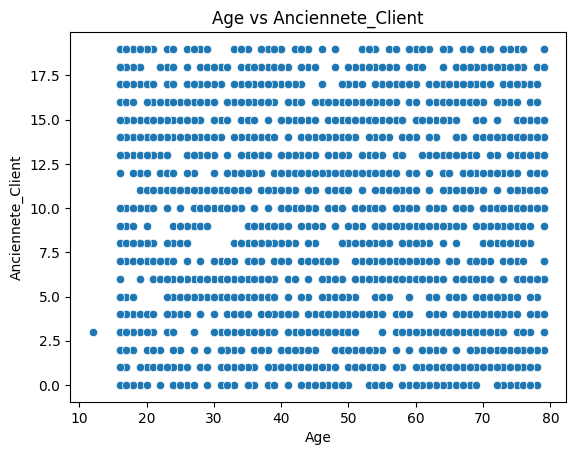

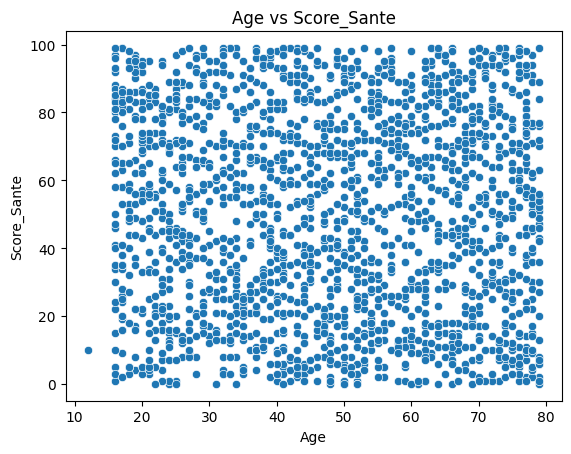

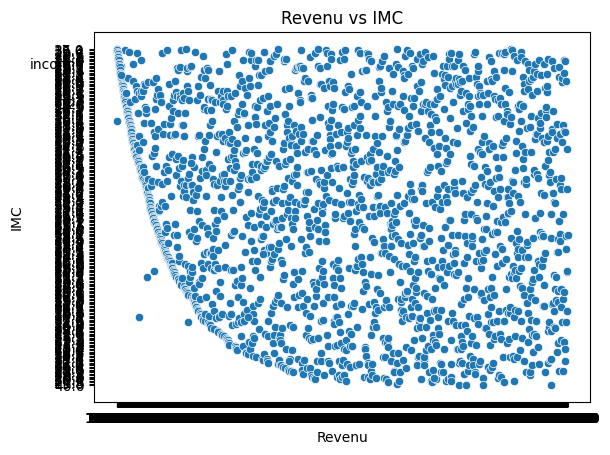

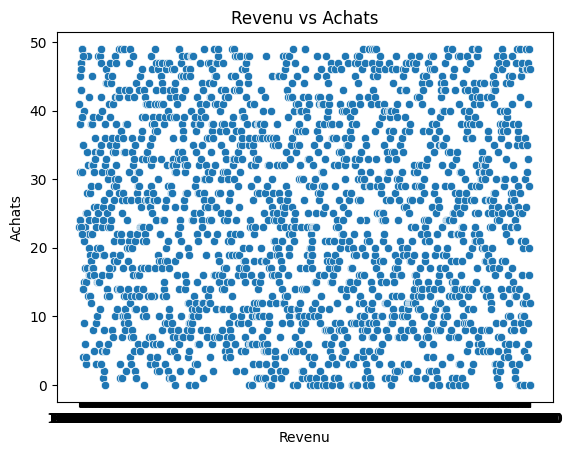

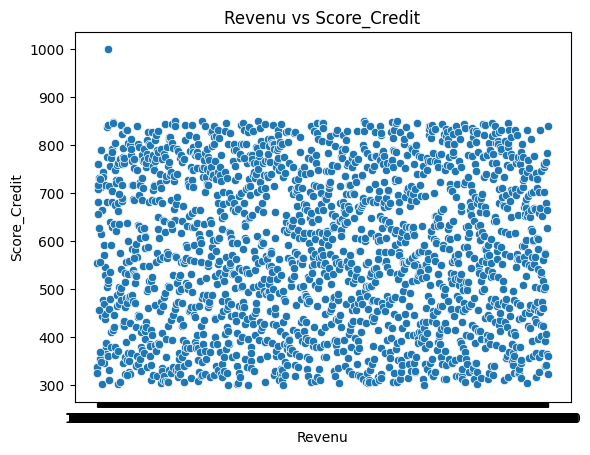

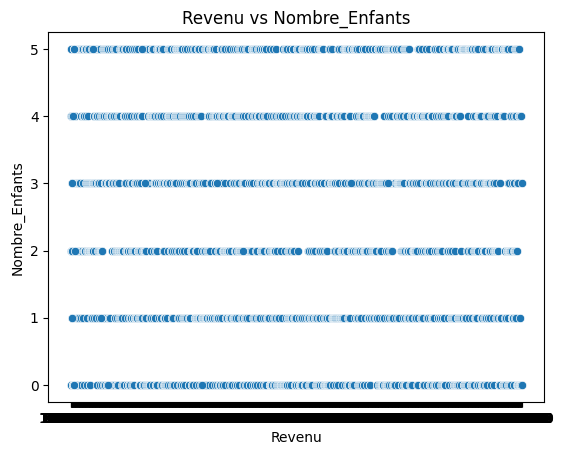

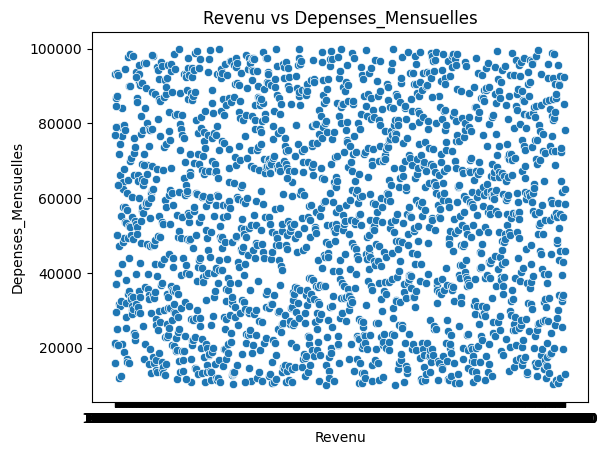

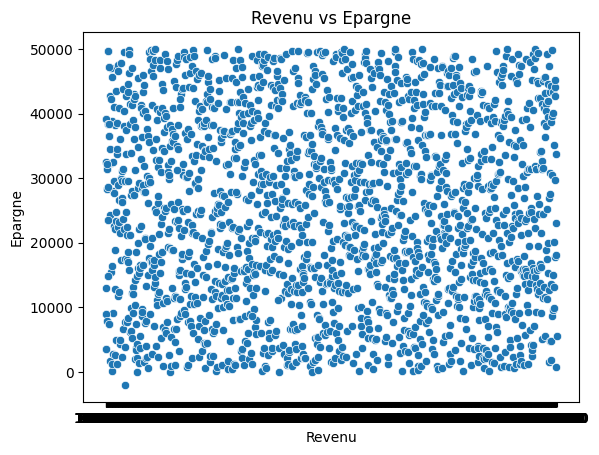

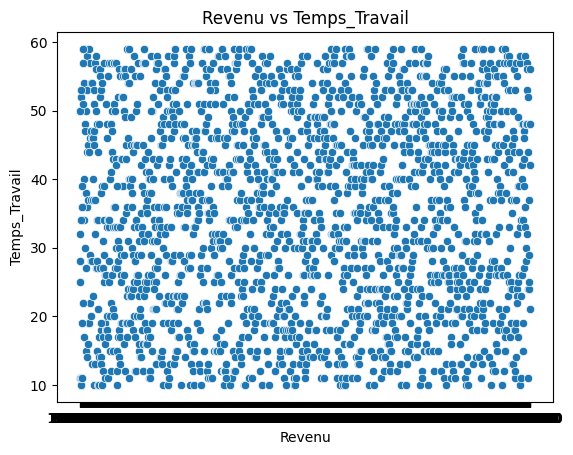

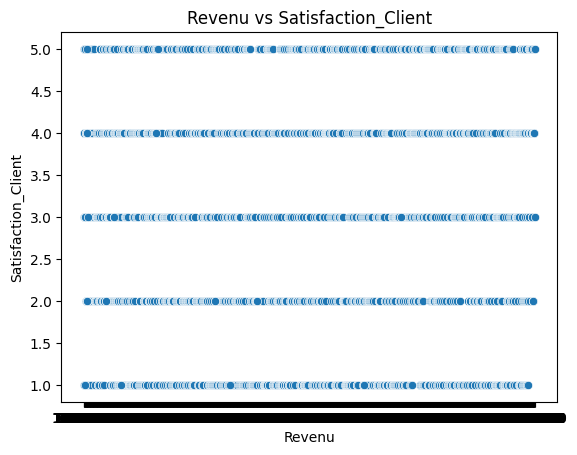

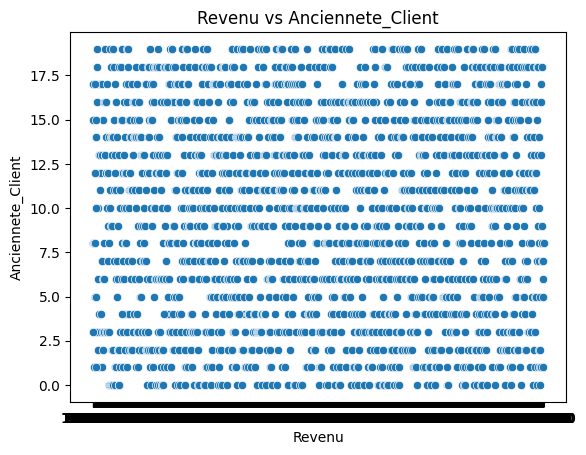

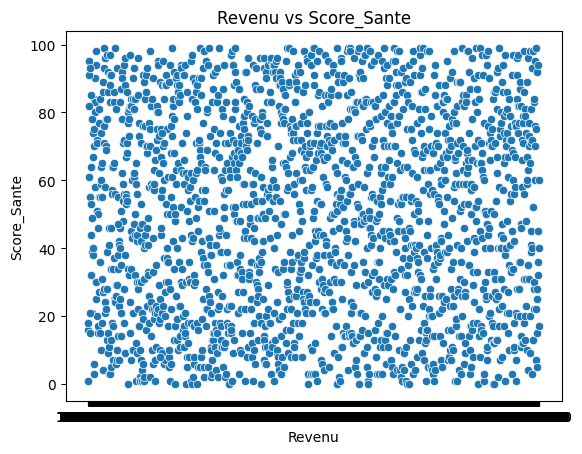

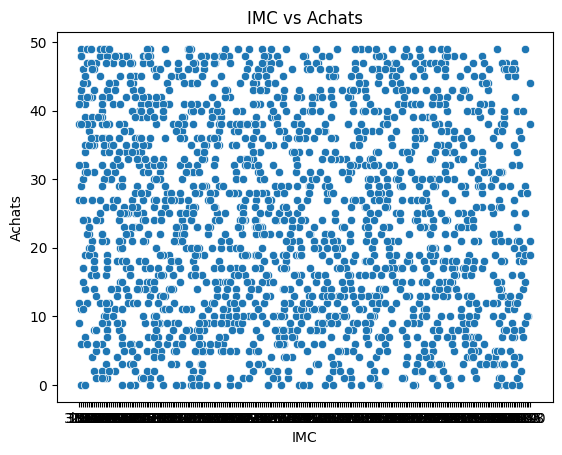

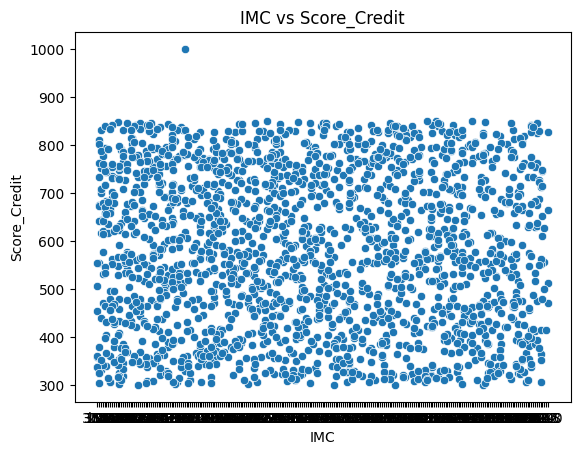

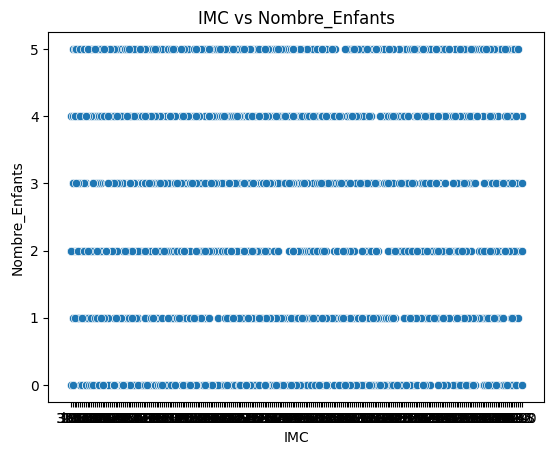

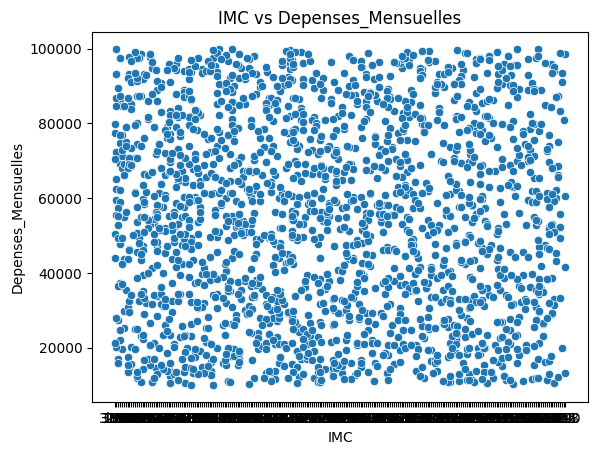

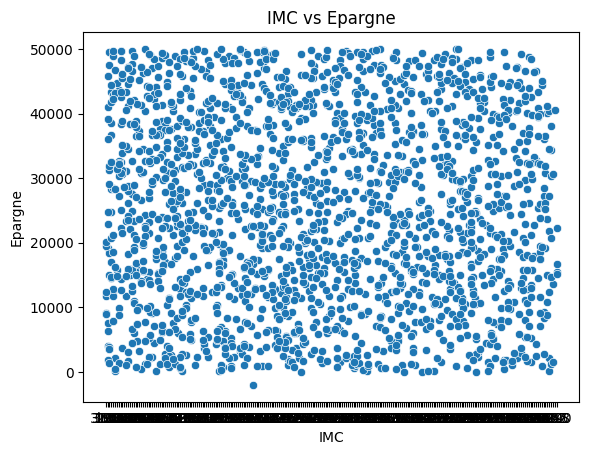

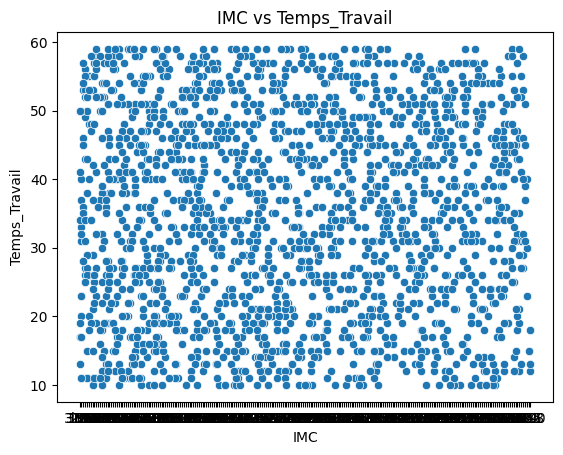

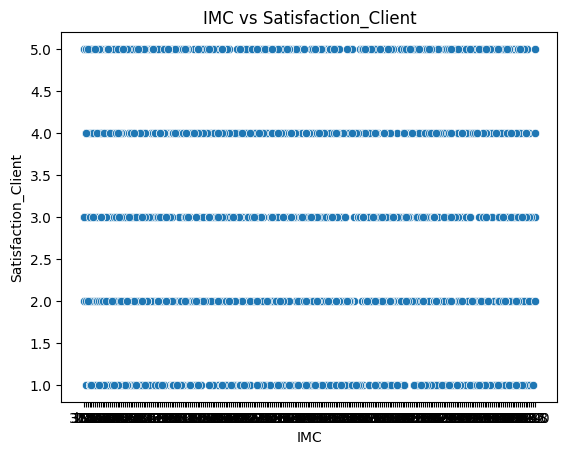

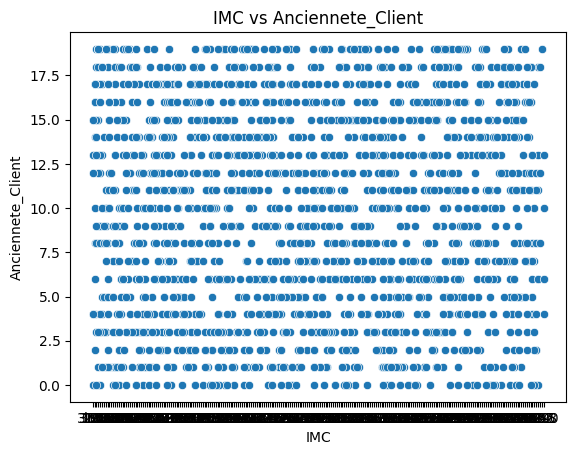

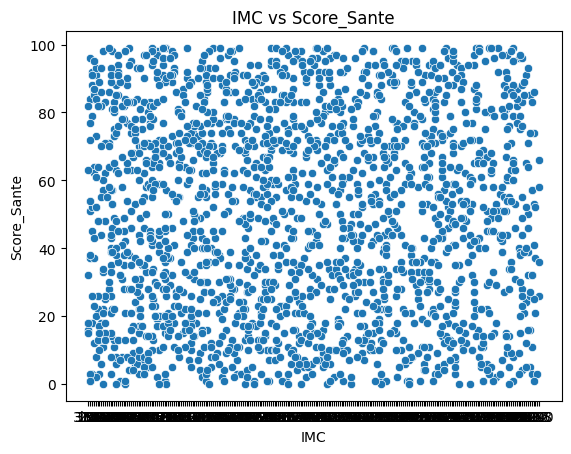

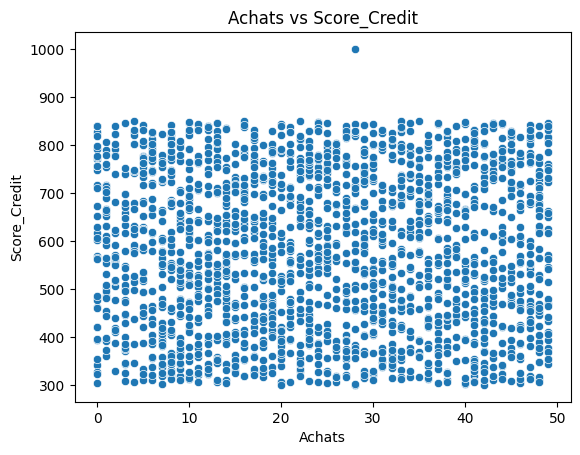

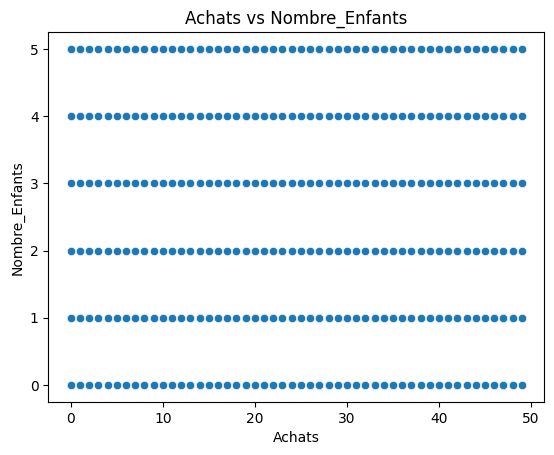

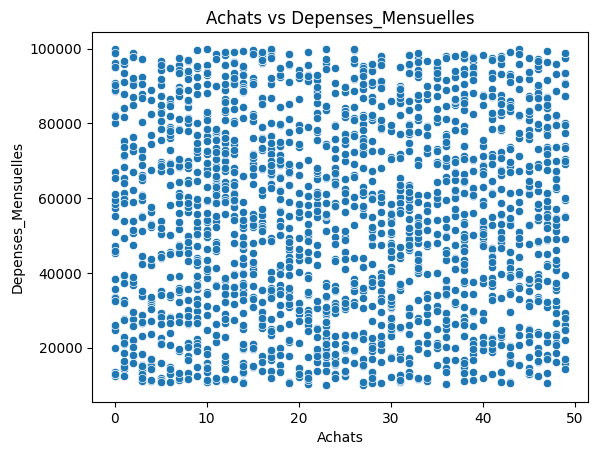

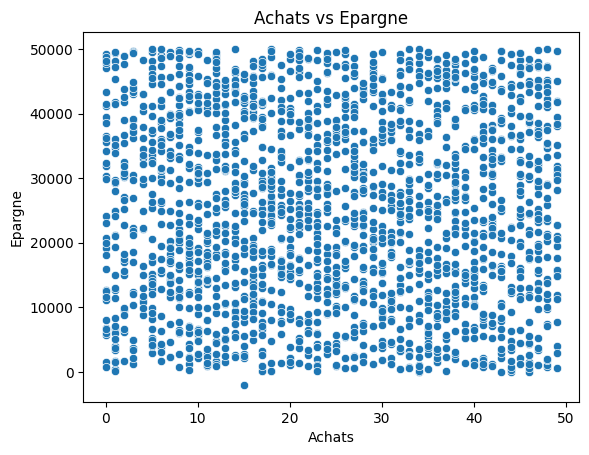

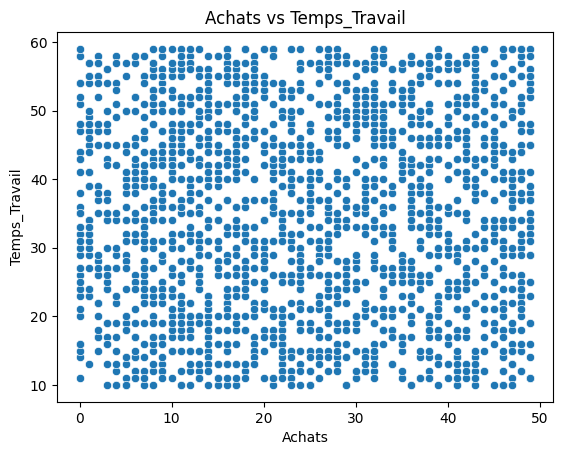

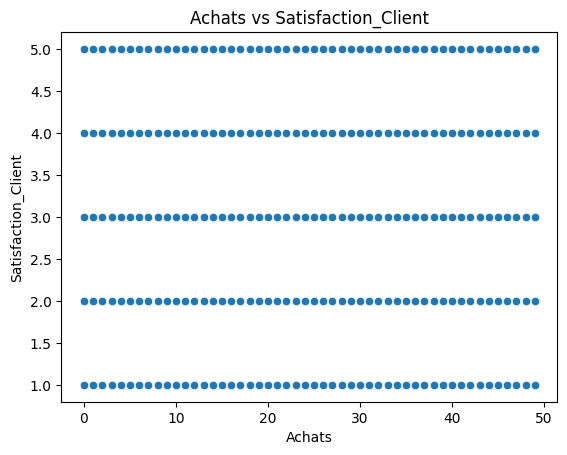

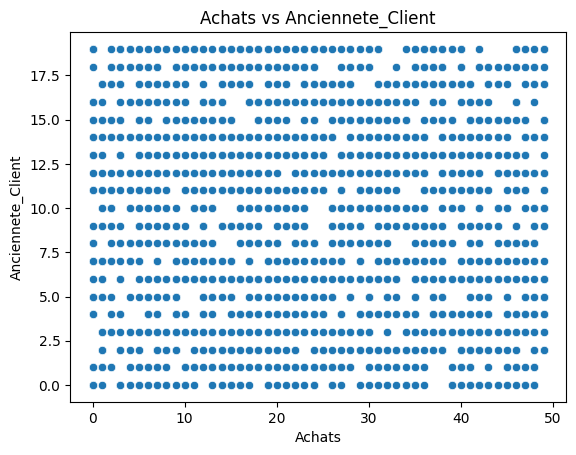

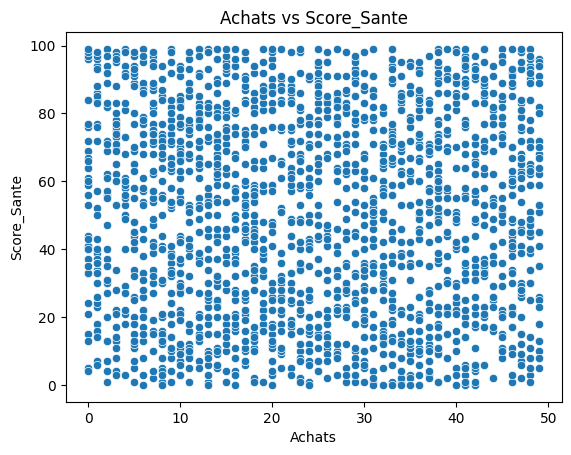

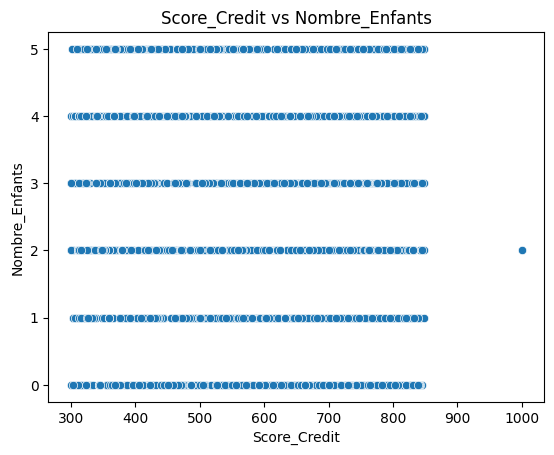

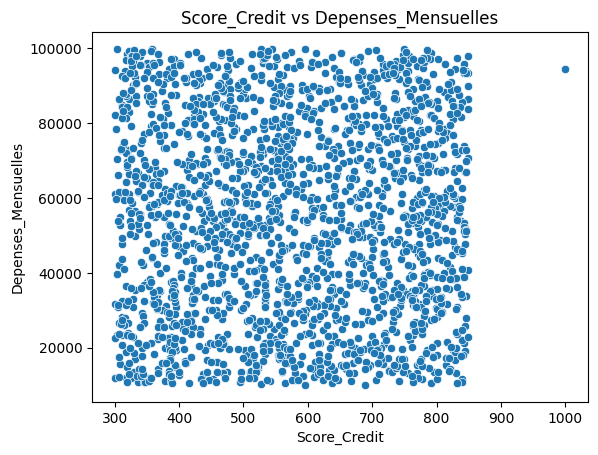

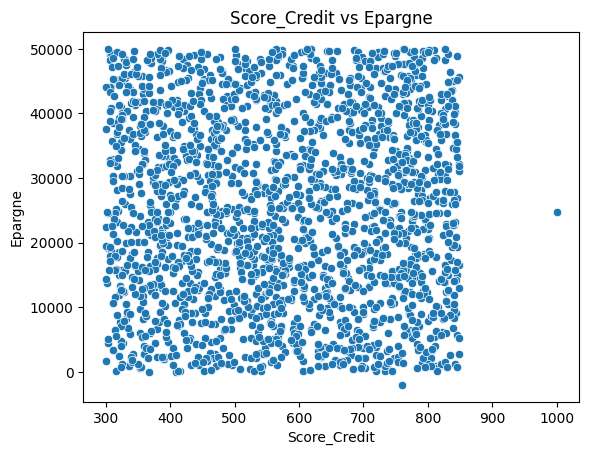

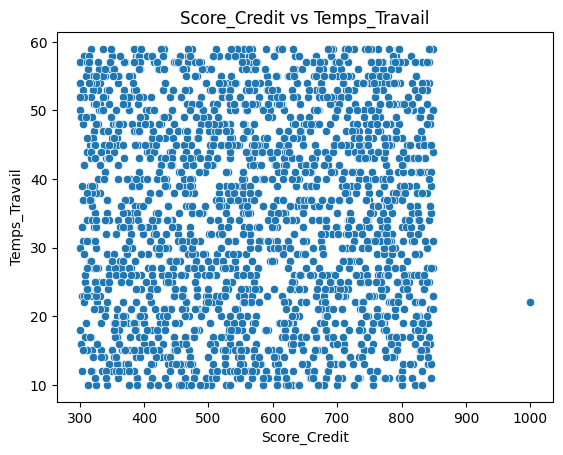

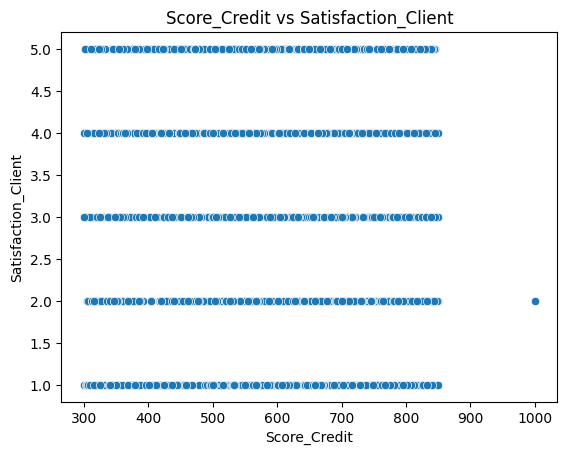

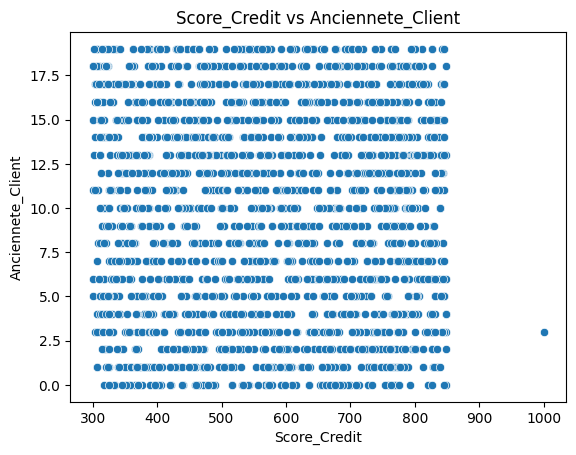

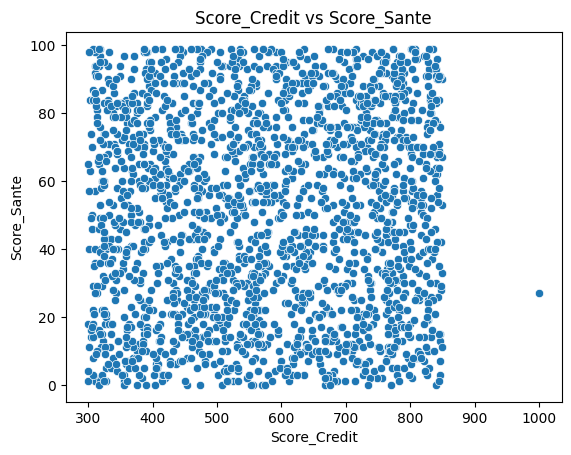

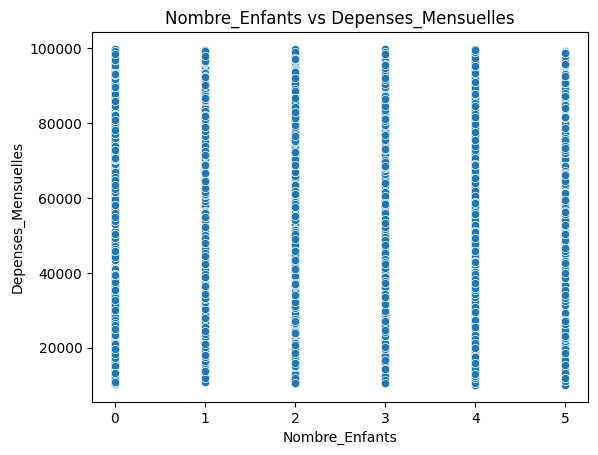

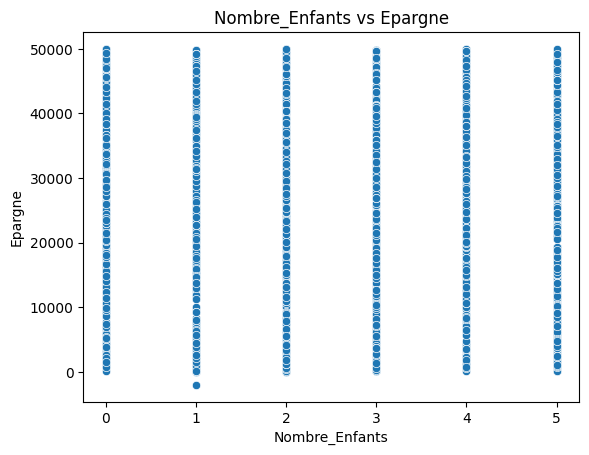

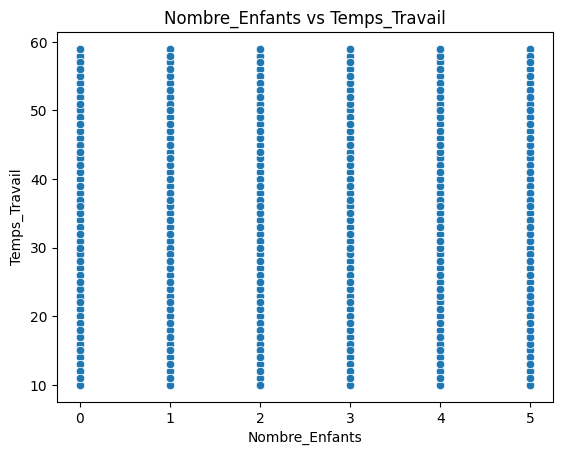

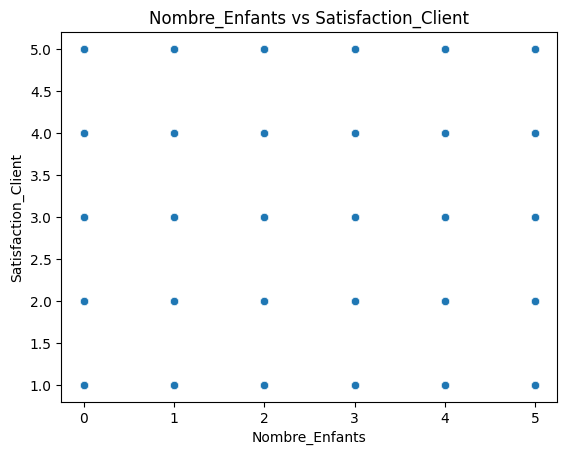

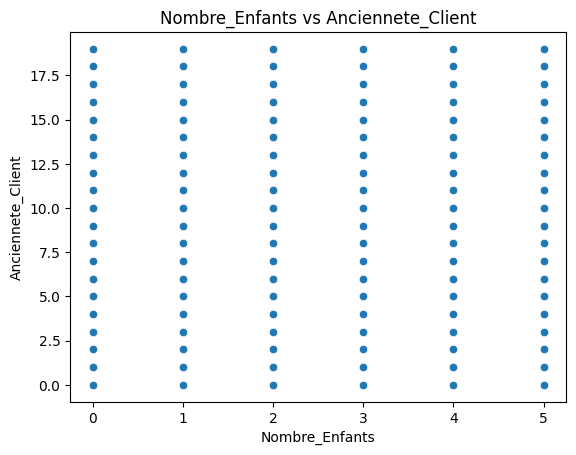

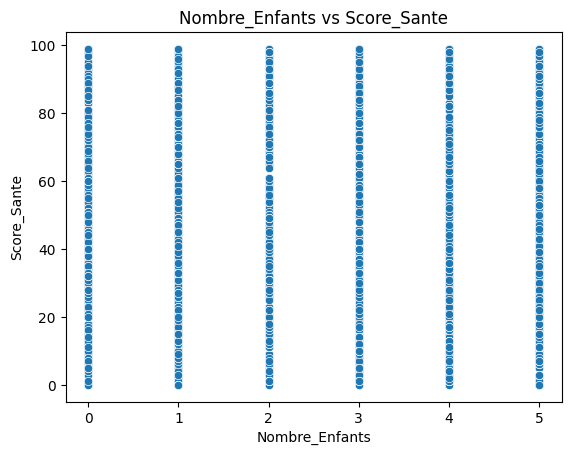

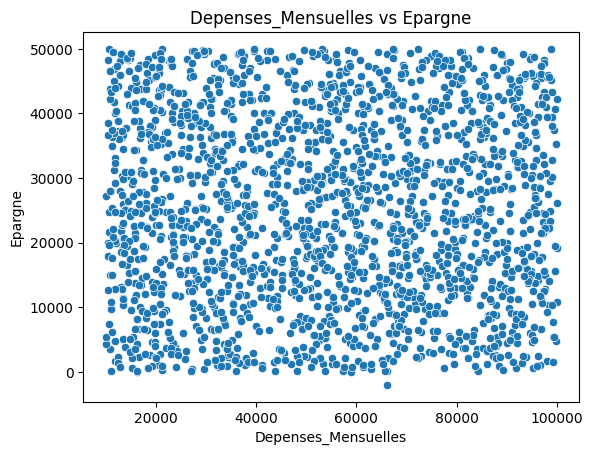

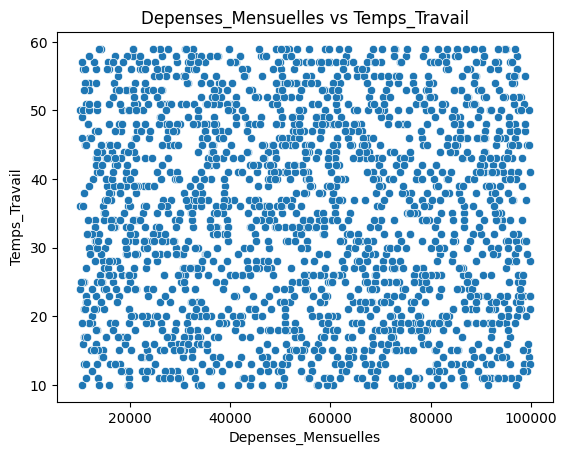

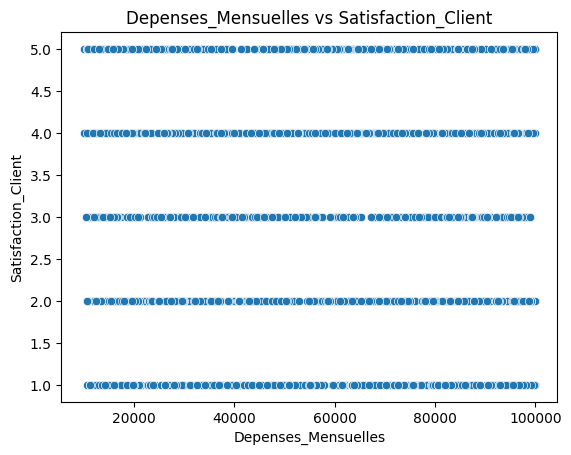

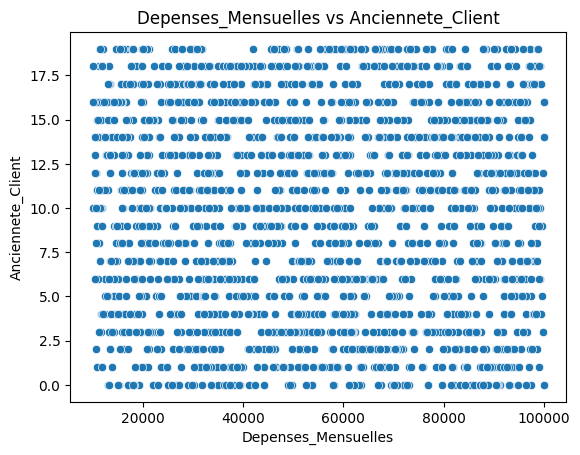

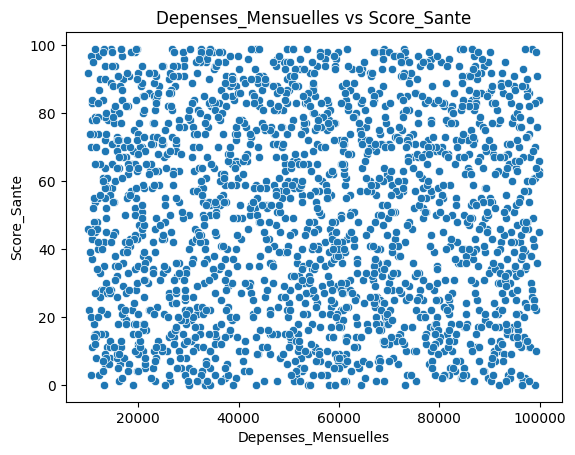

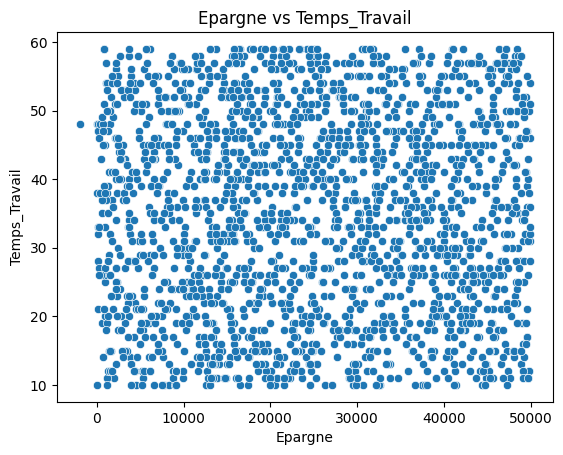

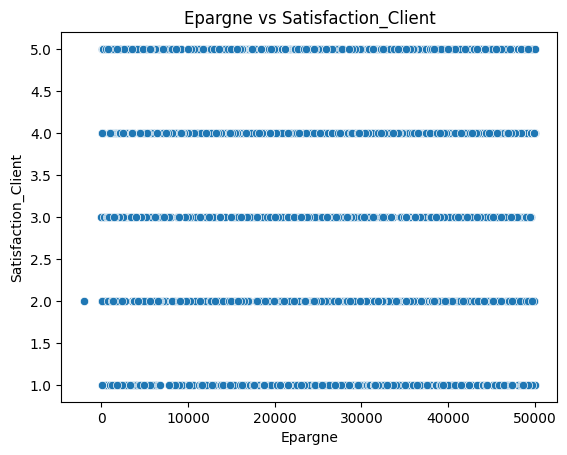

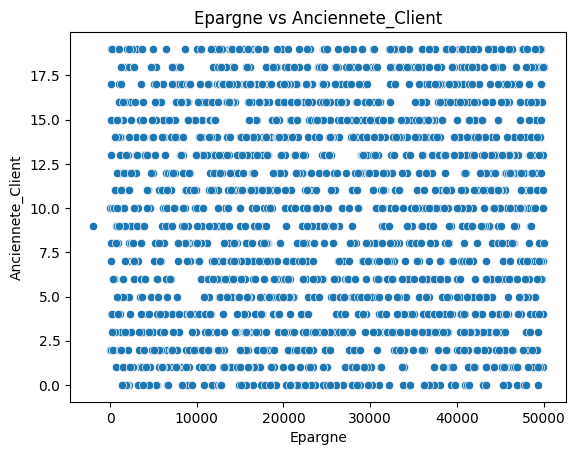

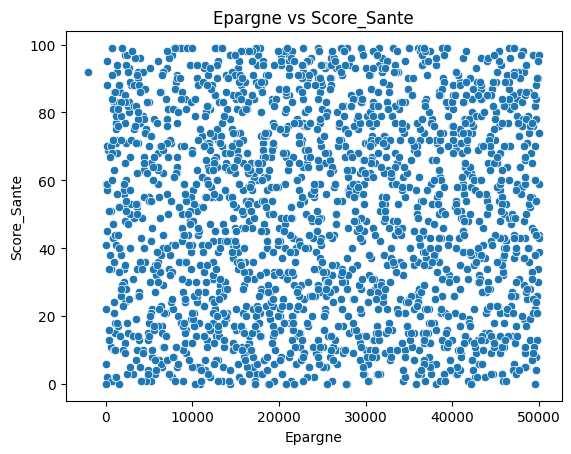

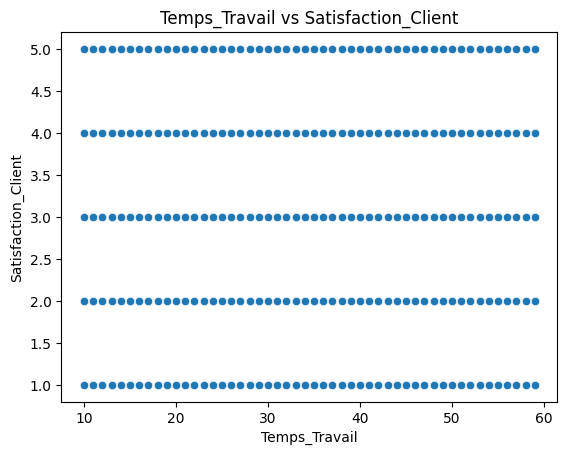

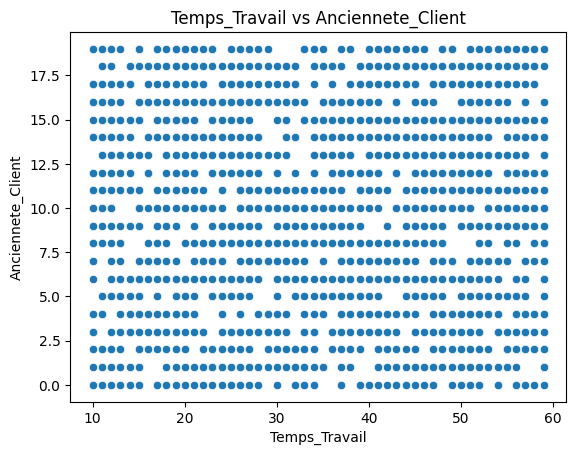

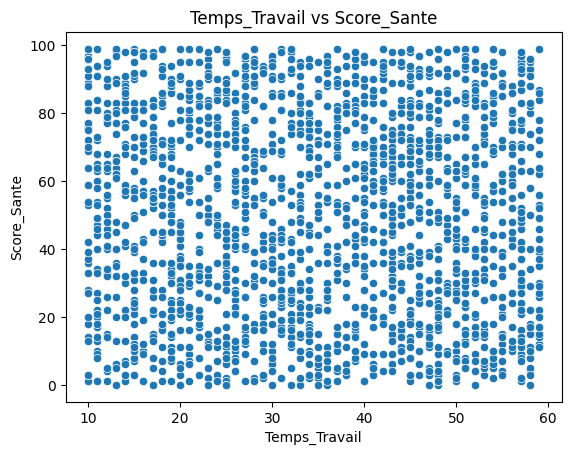

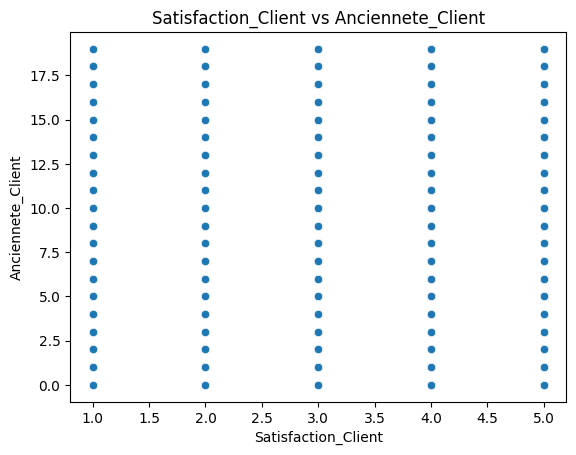

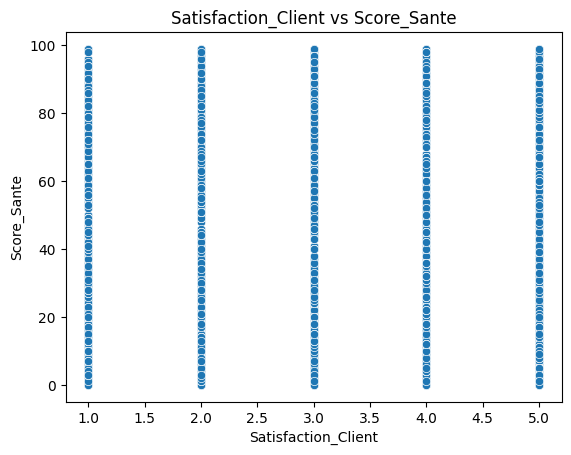

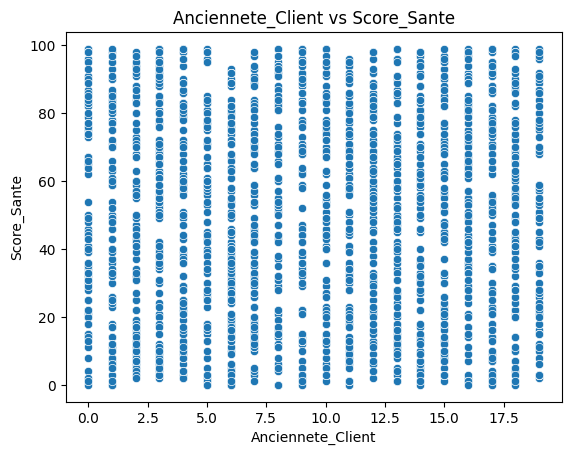

In [35]:
# Heatmap corrélation
plt.figure(figsize=(8,6))
sns.heatmap(df_util[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

# Scatter plots
for i, col1 in enumerate(num_cols):
    for col2 in num_cols[i+1:]:
        
        plt.figure()
        sns.scatterplot(x=df[col1], y=df[col2])
        plt.title(f"{col1} vs {col2}")
        plt.show()

In [36]:
for i, col1 in enumerate(num_cols):
    for col2 in num_cols[i+1:]:

        p1 = shapiro(df_util[col1])[1]
        p2 = shapiro(df_util[col2])[1]

        if p1 > 0.05 and p2 > 0.05:
            corr, p = pearsonr(df_util[col1], df_util[col2])
            test = "Pearson"
        else:
            corr, p = spearmanr(df_util[col1], df_util[col2])
            test = "Spearman"

        if p < 0.05:
            print(f"{col1} - {col2} | {test} | corr={corr:.2f} | p={p:.4f}")


Age - Revenu | Spearman | corr=-0.05 | p=0.0268
Score_Credit - Score_Sante | Spearman | corr=0.04 | p=0.0474
Nombre_Enfants - Epargne | Spearman | corr=-0.06 | p=0.0141


In [37]:
for i, col1 in enumerate(num_cols):
    for col2 in num_cols[i+1:]:

        p1 = shapiro(df_util[col1])[1]
        p2 = shapiro(df_util[col2])[1]

        if p1 > 0.05 and p2 > 0.05:
            corr, p = pearsonr(df_util[col1], df_util[col2])
            test = "Pearson"
        else:
            corr, p = spearmanr(df_util[col1], df_util[col2])
            test = "Spearman"

        print(f"{col1} - {col2} | {test} | corr={corr:.2f} | p={p:.4f}")

Age - Revenu | Spearman | corr=-0.05 | p=0.0268
Age - IMC | Spearman | corr=nan | p=nan
Age - Achats | Spearman | corr=0.00 | p=0.8436
Age - Score_Credit | Spearman | corr=0.01 | p=0.5664
Age - Nombre_Enfants | Spearman | corr=0.00 | p=0.9957
Age - Depenses_Mensuelles | Spearman | corr=nan | p=nan
Age - Epargne | Spearman | corr=-0.01 | p=0.6224
Age - Temps_Travail | Spearman | corr=-0.00 | p=0.8933
Age - Satisfaction_Client | Spearman | corr=0.00 | p=0.8278
Age - Anciennete_Client | Spearman | corr=-0.03 | p=0.2195
Age - Score_Sante | Spearman | corr=-0.03 | p=0.2422
Revenu - IMC | Spearman | corr=nan | p=nan
Revenu - Achats | Spearman | corr=0.03 | p=0.1345


Revenu - Score_Credit | Spearman | corr=-0.02 | p=0.3165
Revenu - Nombre_Enfants | Spearman | corr=-0.02 | p=0.4403
Revenu - Depenses_Mensuelles | Spearman | corr=nan | p=nan
Revenu - Epargne | Spearman | corr=-0.02 | p=0.4093
Revenu - Temps_Travail | Spearman | corr=-0.01 | p=0.5350
Revenu - Satisfaction_Client | Spearman | corr=0.00 | p=0.9084
Revenu - Anciennete_Client | Spearman | corr=-0.03 | p=0.1684
Revenu - Score_Sante | Spearman | corr=-0.03 | p=0.2286
IMC - Achats | Spearman | corr=nan | p=nan
IMC - Score_Credit | Spearman | corr=nan | p=nan
IMC - Nombre_Enfants | Spearman | corr=nan | p=nan
IMC - Depenses_Mensuelles | Spearman | corr=nan | p=nan
IMC - Epargne | Spearman | corr=nan | p=nan
IMC - Temps_Travail | Spearman | corr=nan | p=nan
IMC - Satisfaction_Client | Spearman | corr=nan | p=nan
IMC - Anciennete_Client | Spearman | corr=nan | p=nan
IMC - Score_Sante | Spearman | corr=nan | p=nan
Achats - Score_Credit | Spearman | corr=0.01 | p=0.7893
Achats - Nombre_Enfants | S

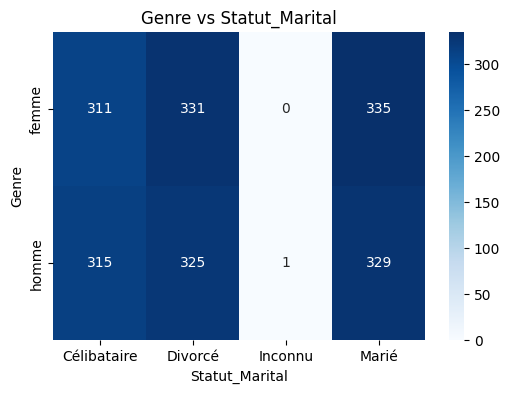

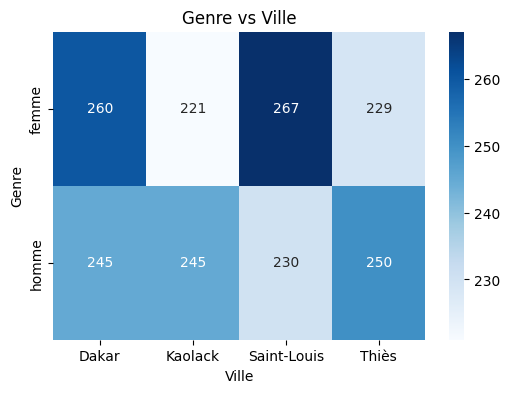

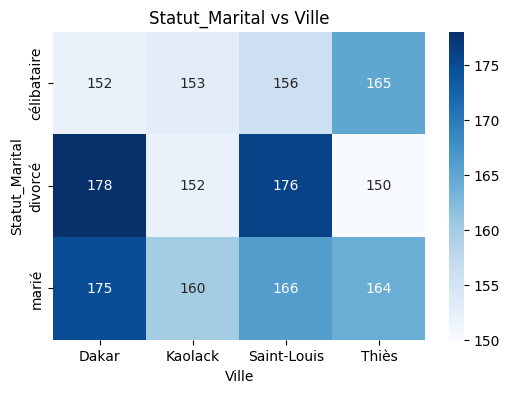

In [38]:
for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i+1:]:
        
        table = pd.crosstab(df_util[col1], df[col2])
        
        plt.figure(figsize=(6,4))
        sns.heatmap(table, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{col1} vs {col2}")
        plt.show()

In [39]:
for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i+1:]:

        table = pd.crosstab(df_util[col1], df_util[col2])

        if table.shape[0] > 1 and table.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(table)

            if p < 0.05:
                print(f"{col1} - {col2} | dépendance | p={p:.4f}")

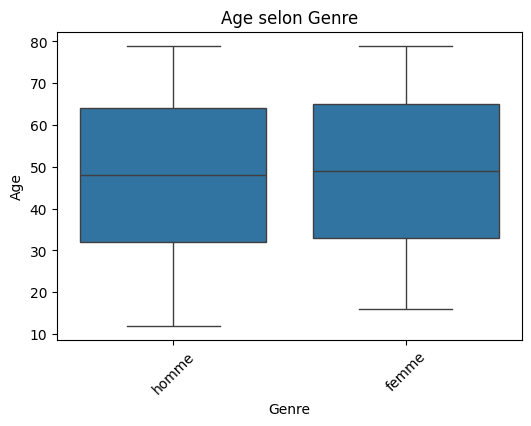

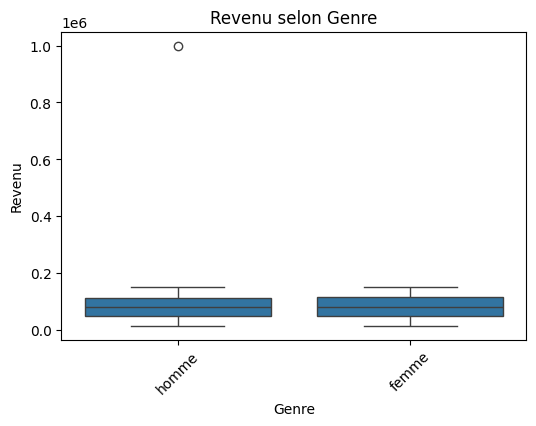

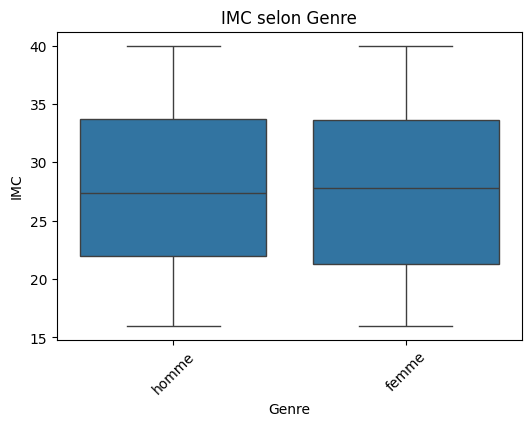

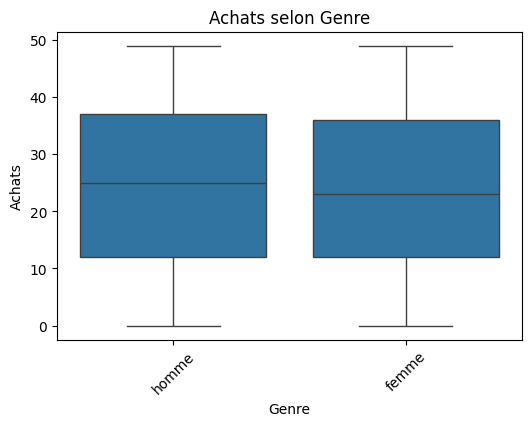

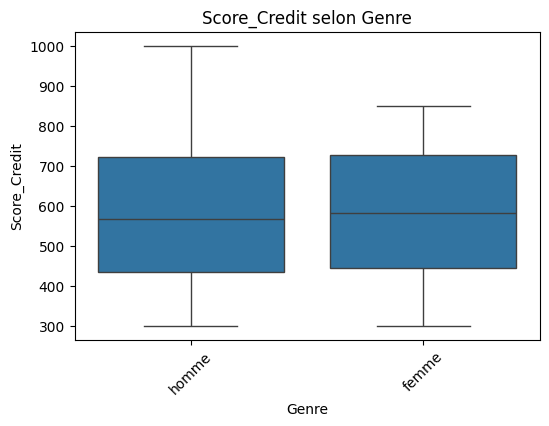

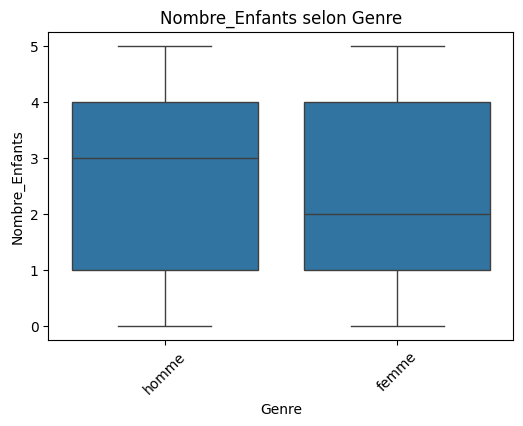

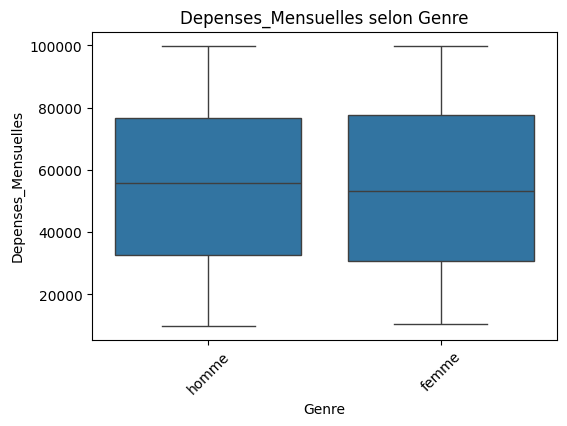

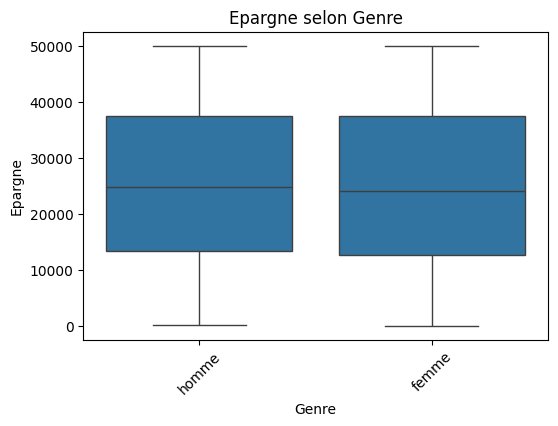

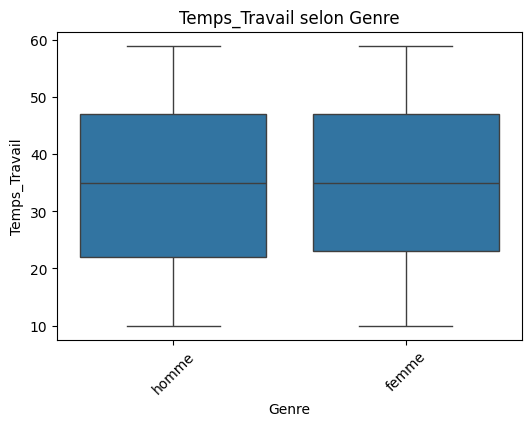

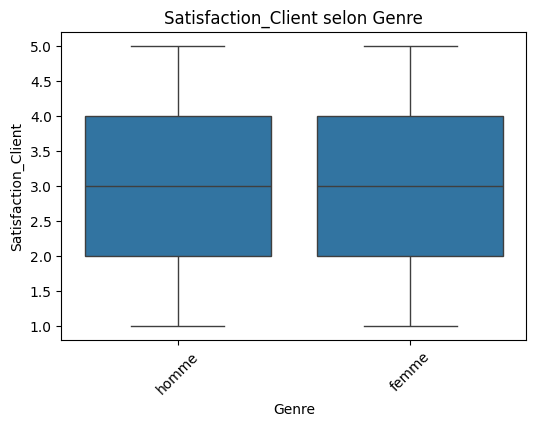

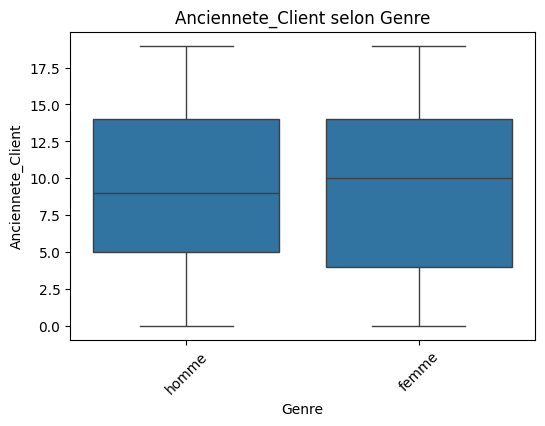

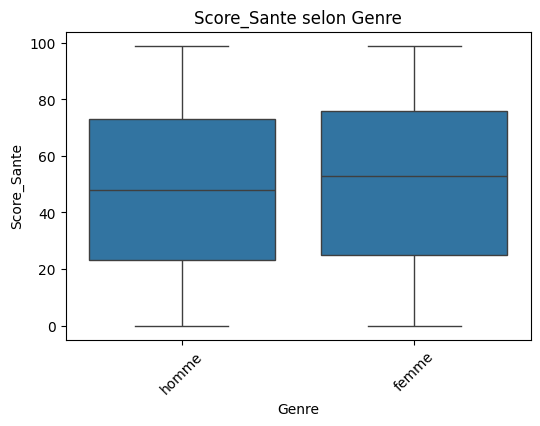

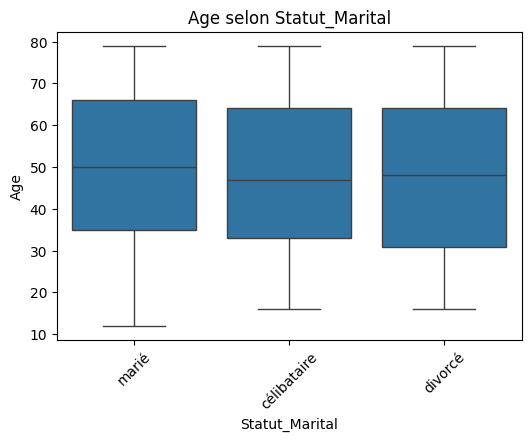

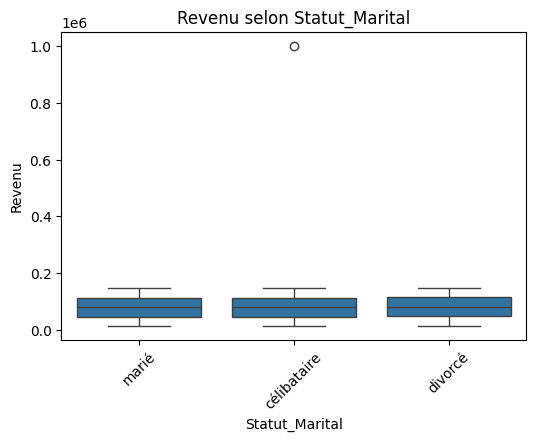

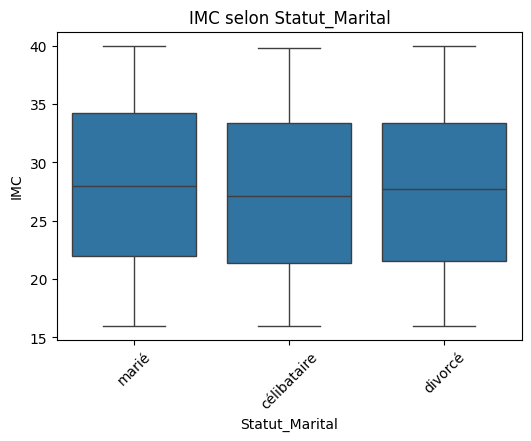

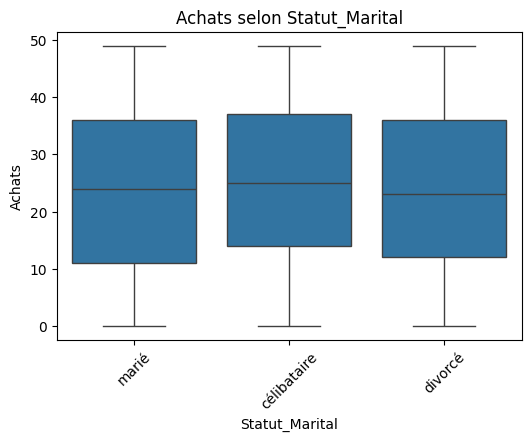

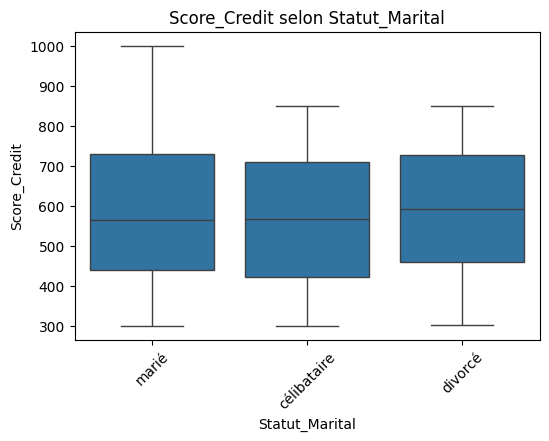

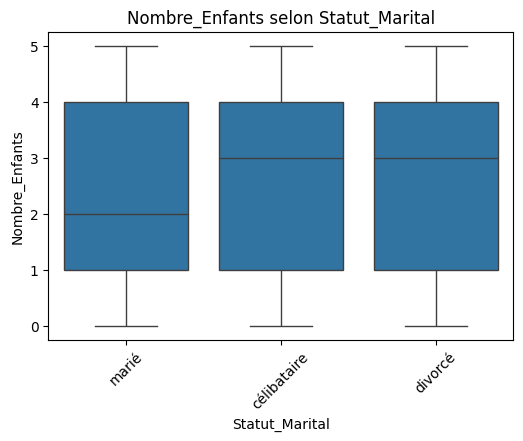

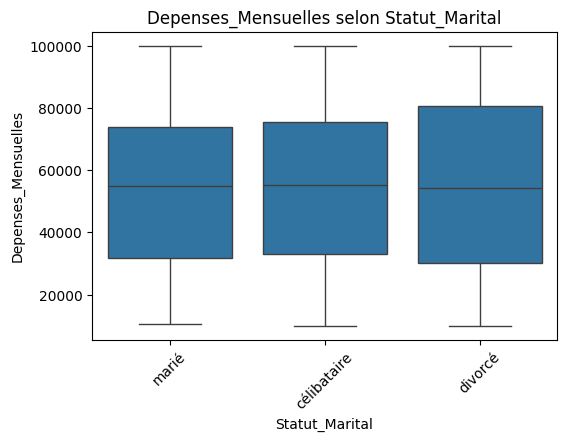

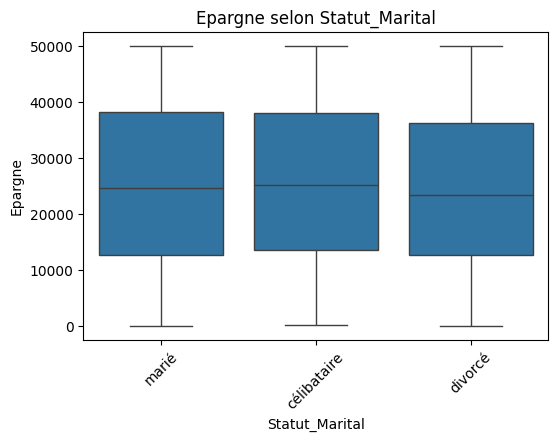

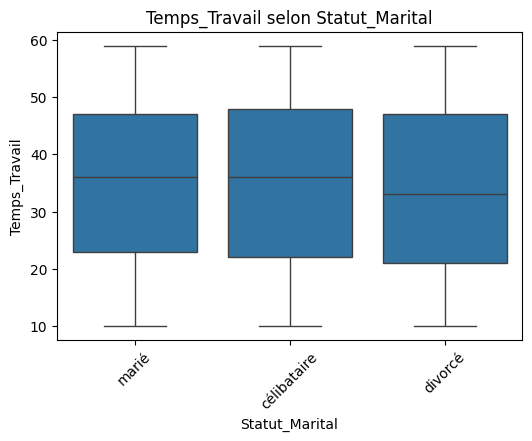

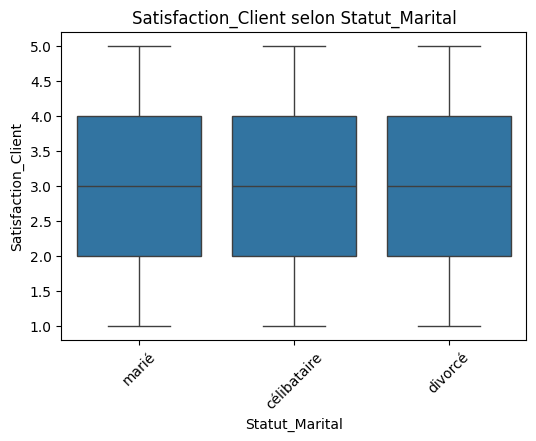

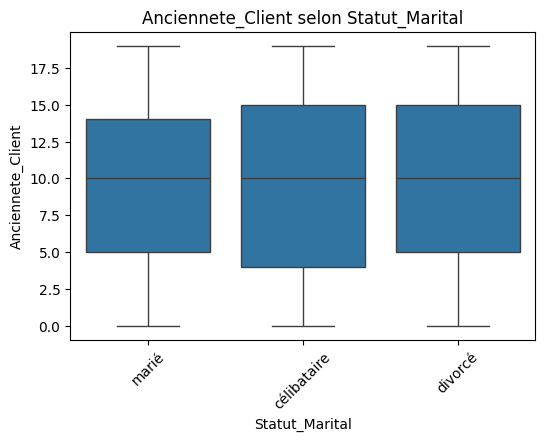

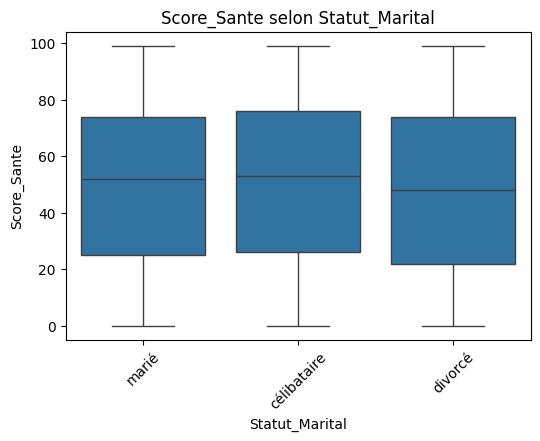

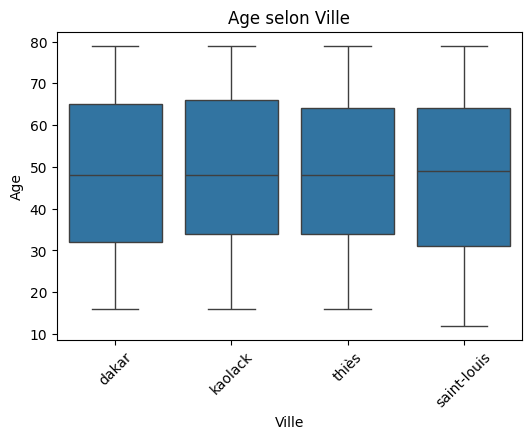

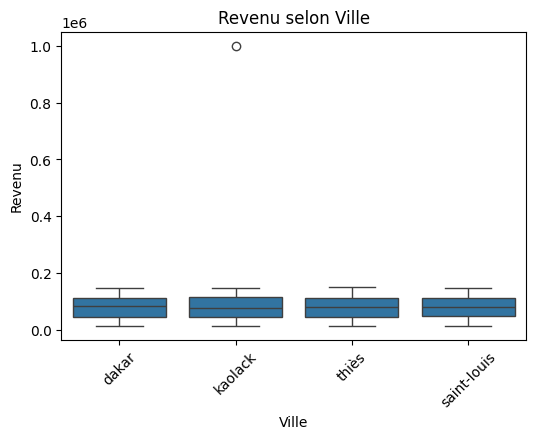

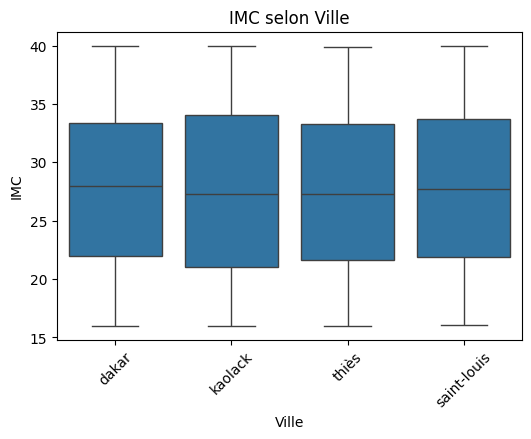

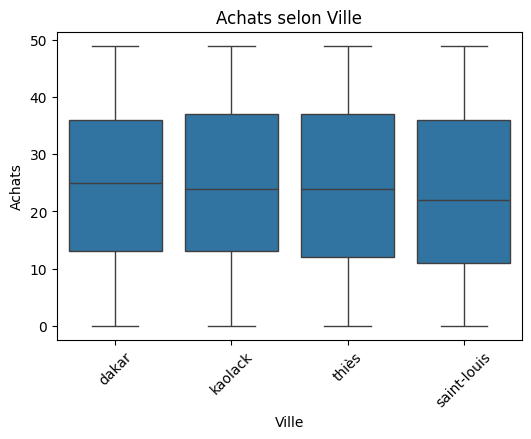

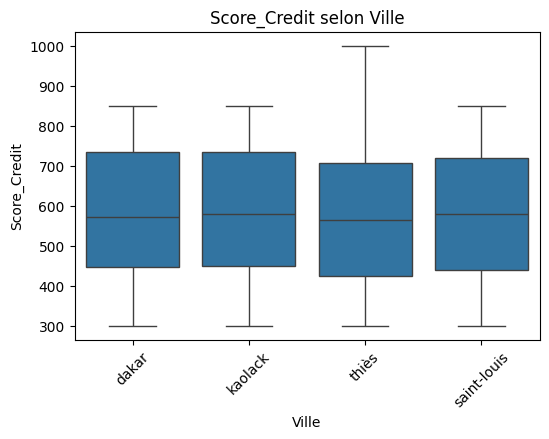

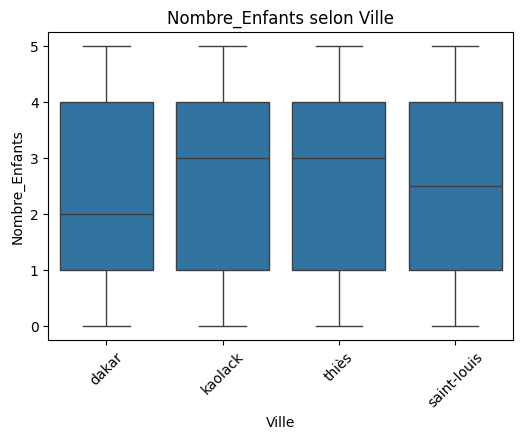

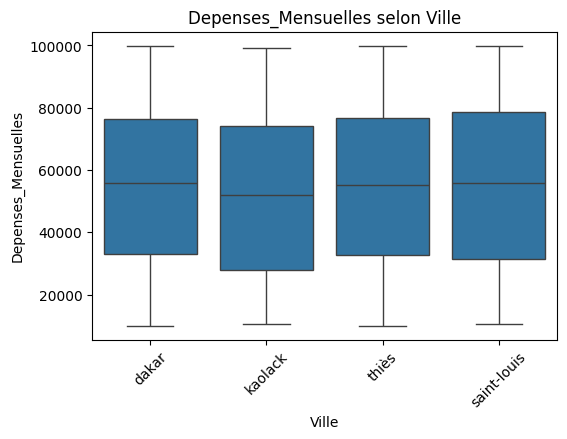

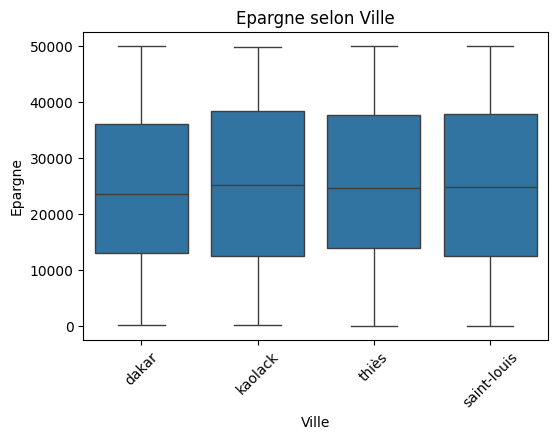

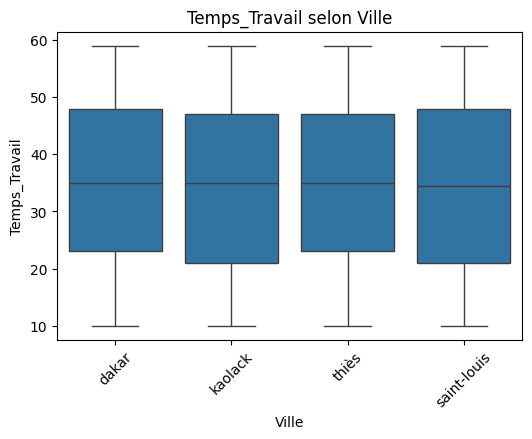

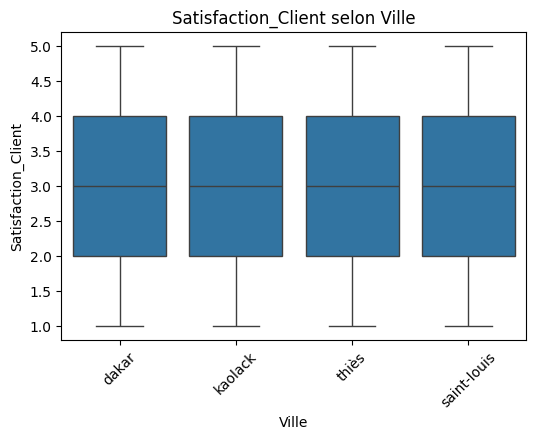

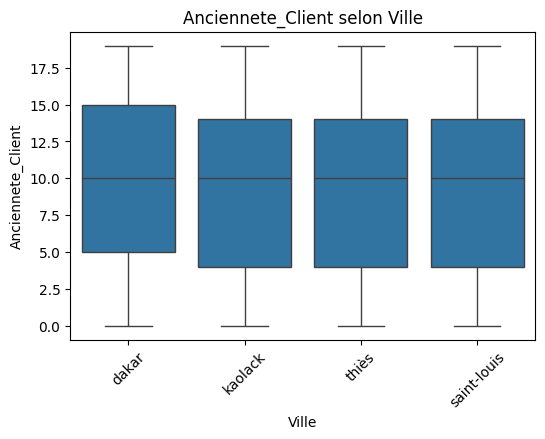

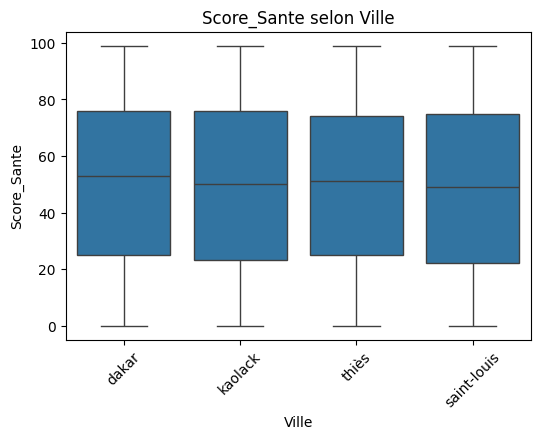

In [40]:
for cat in cat_cols:
    for num in num_cols:
        
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df_util[cat], y=df_util[num])
        plt.title(f"{num} selon {cat}")
        plt.xticks(rotation=45)
        plt.show()

In [41]:
for cat in cat_cols:
    for num in num_cols:

        groups = [df_util[df_util[cat] == val][num] for val in df_util[cat].unique()]

        if len(groups) > 1:

            normal = all(shapiro(g)[1] > 0.05 for g in groups if len(g) > 3)
            var_equal = levene(*groups)[1] > 0.05

            if normal and var_equal:
                stat, p = f_oneway(*groups)
                test = "ANOVA"
            else:
                stat, p = kruskal(*groups)
                test = "Kruskal"

            if p < 0.05:
                print(f"{num} - {cat} | {test} | p={p:.4f}")

C:\Users\samba\AppData\Local\Temp\ipykernel_33128\1492169203.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  var_equal = levene(*groups)[1] > 0.05
C:\Users\samba\AppData\Local\Temp\ipykernel_33128\1492169203.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)


## 5. ANALYSE BIVARIÉE

#### 5.1 Numérique vs Numérique

##### Observation

Corrélations globalement faibles (proches de 0)
Aucune relation linéaire forte détectée
Légère relation entre nombre d'enfants et épargne

##### Interprétation

Les variables sont globalement indépendantes
Absence de relations simples
Le comportement des individus est complexe

##### Conclusion
Les modèles linéaires seront peu performants
Il faudra privilégier des modèles non linéaires

#### 5.2 Catégorielle vs Catégorielle

##### Observation

Aucune association significative entre variables

Tests statistiques non significatifs

#### Interprétation

    Indépendance entre les variables catégorielles

#### Conclusion

    Peu d'interactions exploitables directement

#### 5.3 Numérique vs Catégorielle

##### Observation

Peu de différences significatives entre groupes
Seule relation notable : nombre d'enfants et genre

##### Interprétation

Influence faible des variables catégorielles sur les variables numériques

##### Conclusion

Effet métier limité
Pas de levier direct évident

#### 6. INTERPRÉTATION MÉTIER

##### Observation

Absence de relations fortes entre variables
Comportement très dispersé
Forte variabilité entre individus

##### Interprétation

Les clients ont des comportements hétérogènes
Impossible de généraliser avec des règles simples
Le dataset reflète une réalité complexe

##### Conclusion

Nécessité d'une approche par segmentation
Approche personnalisée recommandée